In [495]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

def get_velgradient(cg,pm,pn):
    u1=u2rho_3d(np.squeeze(cg['u'].values))
    v1=v2rho_3d(np.squeeze(cg['v'].values))
    ux=u2rho_3d((u1[:,:,1:]-u1[:,:,:-1])/np.tile(0.5*(1/pm[:,1:]+1/pm[:,:-1]),[u1.shape[0],1,1]))
    vx=u2rho_3d((v1[:,:,1:]-v1[:,:,:-1])/np.tile(0.5*(1/pm[:,1:]+1/pm[:,:-1]),[u1.shape[0],1,1]))
    uy=v2rho_3d((u1[:,1:,:]-u1[:,:-1,:])/np.tile(0.5*(1/pn[1:,:]+1/pn[:-1,:]),[u1.shape[0],1,1]))
    vy=v2rho_3d((v1[:,1:,:]-v1[:,:-1,:])/np.tile(0.5*(1/pn[1:,:]+1/pn[:-1,:]),[u1.shape[0],1,1]))
    return ux,vx,uy,vy

def get_traj(w):
    lon=w['lon'].values
    lat=w['lat'].values
    return lon,lat

from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

def create_particle_heatmap(lon289_w_r, lonr, latr=None, lat289_w_r=None):
    """
    修复版本：正确处理粒子纬度数据
    """
    # 获取网格信息
    ny, nx = lonr.shape
    
    # 将网格展平为点集
    if latr is not None:
        grid_points = np.column_stack([lonr.ravel(), latr.ravel()])
    else:
        grid_points = np.column_stack([lonr.ravel(), np.zeros(lonr.size)])
    
    # 创建KDTree
    tree = cKDTree(grid_points)
    
    # 初始化热点图
    heatmap = np.zeros((ny, nx))
    
    # 获取粒子数和时间步数
    n_particles, n_time = lon289_w_r.shape
    
    print(f"处理 {n_particles} 个粒子，{n_time} 个时间步...")
    
    for t in range(n_time):
        # 获取当前时间步所有粒子的经度
        particle_lons = lon289_w_r[:, t]
        
        # 处理有效数据
        valid_mask = ~np.isnan(particle_lons)
        valid_lons = particle_lons[valid_mask]
        
        if len(valid_lons) == 0:
            continue
            
        # 构建粒子位置数组
        if latr is not None and lat289_w_r is not None:
            # 获取对应粒子的纬度数据
            particle_lats = lat289_w_r[:, t][valid_mask]  # 关键修复！
            particle_points = np.column_stack([valid_lons, particle_lats])
        else:
            # 如果只有经度，使用虚拟纬度
            particle_points = np.column_stack([valid_lons, np.zeros(len(valid_lons))])
        
        # 查找最近网格点
        distances, indices = tree.query(particle_points, k=1)
        
        # 统计每个网格点的粒子数
        unique_indices, counts = np.unique(indices, return_counts=True)
        
        # 更新热点图
        for idx, count in zip(unique_indices, counts):
            i, j = np.unravel_index(idx, (ny, nx))
            heatmap[i, j] += count
    
    return heatmap

def create_particle_pdf(lon289_w_r, lonr, latr=None, lat289_w_r=None):
    """
    计算粒子概率密度函数（总和为1）
    """
    ny, nx = lonr.shape
    
    # 创建网格点
    if latr is not None:
        grid_points = np.column_stack([lonr.ravel(), latr.ravel()])
    else:
        grid_points = np.column_stack([lonr.ravel(), np.zeros(lonr.size)])
    
    tree = cKDTree(grid_points)
    
    # 初始化概率密度数组
    pdf = np.zeros((ny, nx))
    
    n_particles, n_time = lon289_w_r.shape
    total_particle_observations = 0  # 总观测次数
    
    print(f"计算粒子PDF，{n_particles} 个粒子，{n_time} 个时间步...")
    
    for t in range(n_time):
        particle_lons = lon289_w_r[:, t]
        valid_mask = ~np.isnan(particle_lons)
        valid_lons = particle_lons[valid_mask]
        
        if len(valid_lons) == 0:
            continue
            
        # 构建粒子位置
        if latr is not None and lat289_w_r is not None:
            particle_lats = lat289_w_r[:, t][valid_mask]
            particle_points = np.column_stack([valid_lons, particle_lats])
        else:
            particle_points = np.column_stack([valid_lons, np.zeros(len(valid_lons))])
        
        # 查找最近网格点
        distances, indices = tree.query(particle_points, k=1)
        
        # 统计每个网格点的粒子数（当前时间步）
        unique_indices, counts = np.unique(indices, return_counts=True)
        
        # 更新PDF
        for idx, count in zip(unique_indices, counts):
            i, j = np.unravel_index(idx, (ny, nx))
            pdf[i, j] += count
        
        total_particle_observations += len(valid_lons)
    
    # 归一化为概率密度（总和为1）
    if total_particle_observations > 0:
        pdf = pdf / total_particle_observations
    else:
        pdf = np.zeros((ny, nx))
    
    # 验证总和是否为1
    print(f"PDF总和: {np.sum(pdf):.6f}")
    print(f"总粒子观测次数: {total_particle_observations}")
    
    return pdf, total_particle_observations

# 使用示例


In [381]:
grid=xr.open_dataset('/meddy/simingzhang/Data/RB_iceland_data/niskin2km_500m_grd.nc')
cgw=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/wavecase_modified_vel_cg_kaiser_corr.nc')
cgnw=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/nowavecase_modified_vel_cg_kaiser_corr.nc')

lonr=cgw['lon_rho'].values
latr=cgw['lat_rho'].values
pm=grid['pm'].values
pn=grid['pn'].values
f=grid['f'].values
ux_w,vx_w,uy_w,vy_w=get_velgradient(cgw,pm,pn)
ux_nw,vx_nw,uy_nw,vy_nw=get_velgradient(cgnw,pm,pn)

Ro_w=(vx_w-uy_w)/np.tile(f,[ux_w.shape[0],1,1])
divof_w=(ux_w+vy_w)/np.tile(f,[ux_w.shape[0],1,1])
Ro_nw=(vx_nw-uy_nw)/np.tile(f,[ux_w.shape[0],1,1])
divof_nw=(ux_nw+vy_nw)/np.tile(f,[ux_w.shape[0],1,1])

In [382]:
tindex=210
lonmin=np.nanmin(lonr)
latmin=np.nanmin(latr)
lonmax=np.nanmax(lonr)
latmax=np.nanmax(latr)
tt=tindex

w289_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T89.5days.nc')
lon289_w_r,lat289_w_r=get_traj(w289_r)
lon289_w_r_1mon=lon289_w_r[:,:tt]
lat289_w_r_1mon=lat289_w_r[:,:tt]
lon289_w_r_2mon=lon289_w_r[:,tt:]
lat289_w_r_2mon=lat289_w_r[:,tt:]

w625_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P625T89.5days.nc')
lon625_w_r,lat625_w_r=get_traj(w625_r)
lon625_w_r_1mon=lon625_w_r[:,:tt]
lat625_w_r_1mon=lat625_w_r[:,:tt]
lon625_w_r_2mon=lon625_w_r[:,tt:]
lat625_w_r_2mon=lat625_w_r[:,tt:]

w1089_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P1089T89.5days.nc')
lon1089_w_r,lat1089_w_r=get_traj(w1089_r)
lon1089_w_r_1mon=lon1089_w_r[:,:tt]
lat1089_w_r_1mon=lat1089_w_r[:,:tt]
lon1089_w_r_2mon=lon1089_w_r[:,tt:]
lat1089_w_r_2mon=lat1089_w_r[:,tt:]

nw289_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P289T89.5days.nc')
lon289_nw_r,lat289_nw_r=get_traj(nw289_r)
lon289_nw_r_1mon=lon289_nw_r[:,:tt]
lat289_nw_r_1mon=lat289_nw_r[:,:tt]
lon289_nw_r_2mon=lon289_nw_r[:,tt:]
lat289_nw_r_2mon=lat289_nw_r[:,tt:]

nw625_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P625T89.5days.nc')
lon625_nw_r,lat625_nw_r=get_traj(nw625_r)
lon625_nw_r_1mon=lon625_nw_r[:,:tt]
lat625_nw_r_1mon=lat625_nw_r[:,:tt]
lon625_nw_r_2mon=lon625_nw_r[:,tt:]
lat625_nw_r_2mon=lat625_nw_r[:,tt:]

nw1089_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P1089T89.5days.nc')
lon1089_nw_r,lat1089_nw_r=get_traj(nw1089_r)
lon1089_nw_r_1mon=lon1089_nw_r[:,:tt]
lat1089_nw_r_1mon=lat1089_nw_r[:,:tt]
lon1089_nw_r_2mon=lon1089_nw_r[:,tt:]
lat1089_nw_r_2mon=lat1089_nw_r[:,tt:]

#################################small region
w289_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P289T89.5days.nc')
lon289_w_s,lat289_w_s=get_traj(w289_s)
lon289_w_s_1mon=lon289_w_s[:,:tt]
lat289_w_s_1mon=lat289_w_s[:,:tt]
lon289_w_s_2mon=lon289_w_s[:,tt:]
lat289_w_s_2mon=lat289_w_s[:,tt:]

w625_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P625T89.5days.nc')
lon625_w_s,lat625_w_s=get_traj(w625_s)
lon625_w_s_1mon=lon625_w_s[:,:tt]
lat625_w_s_1mon=lat625_w_s[:,:tt]
lon625_w_s_2mon=lon625_w_s[:,tt:]
lat625_w_s_2mon=lat625_w_s[:,tt:]

w1089_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P1089T89.5days.nc')
lon1089_w_s,lat1089_w_s=get_traj(w1089_s)
lon1089_w_s_1mon=lon1089_w_s[:,:tt]
lat1089_w_s_1mon=lat1089_w_s[:,:tt]
lon1089_w_s_2mon=lon1089_w_s[:,tt:]
lat1089_w_s_2mon=lat1089_w_s[:,tt:]

nw289_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P289T89.5days.nc')
lon289_nw_s,lat289_nw_s=get_traj(nw289_s)
lon289_nw_s_1mon=lon289_nw_s[:,:tt]
lat289_nw_s_1mon=lat289_nw_s[:,:tt]
lon289_nw_s_2mon=lon289_nw_s[:,tt:]
lat289_nw_s_2mon=lat289_nw_s[:,tt:]

nw625_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P625T89.5days.nc')
lon625_nw_s,lat625_nw_s=get_traj(nw625_s)
lon625_nw_s_1mon=lon625_nw_s[:,:tt]
lat625_nw_s_1mon=lat625_nw_s[:,:tt]
lon625_nw_s_2mon=lon625_nw_s[:,tt:]
lat625_nw_s_2mon=lat625_nw_s[:,tt:]

nw1089_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P1089T89.5days.nc')
lon1089_nw_s,lat1089_nw_s=get_traj(nw1089_s)
lon1089_nw_s_1mon=lon1089_nw_s[:,:tt]
lat1089_nw_s_1mon=lat1089_nw_s[:,:tt]
lon1089_nw_s_2mon=lon1089_nw_s[:,tt:]
lat1089_nw_s_2mon=lat1089_nw_s[:,tt:]

In [383]:
cgf=xr.open_dataset('/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_all_hf_uni.0002.nc')
Th4w=cgf['Th2'].values

cgm=xr.open_dataset('/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_all_smooth_uni.0002.nc')
Th4nw=cgm['Th2'].values

In [384]:
Ro_rms_w_e=np.sqrt(np.nanmean(Ro_w**2,axis=(1,2)))
Ro_rms_nw_e=np.sqrt(np.nanmean(Ro_nw**2,axis=(1,2)))

In [385]:
Ro_rms_w_e.shape,np.arange(2148).shape
# tindex=210

((2148,), (2148,))

In [405]:
# plt.plot(np.arange(2148),Ro_rms_w_e)
# plt.plot(np.arange(2148),Ro_rms_nw_e)
# plt.plot(np.arange(2148)[tindex],Ro_rms_w_e[tindex],marker='x',color='r')

/tmp/ipykernel_652960/342273854.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
/tmp/ipykernel_652960/342273854.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
/tmp/ipykernel_652960/342273854.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
/tmp/ipykernel_652960/342273854.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
/tmp/ipykernel_6

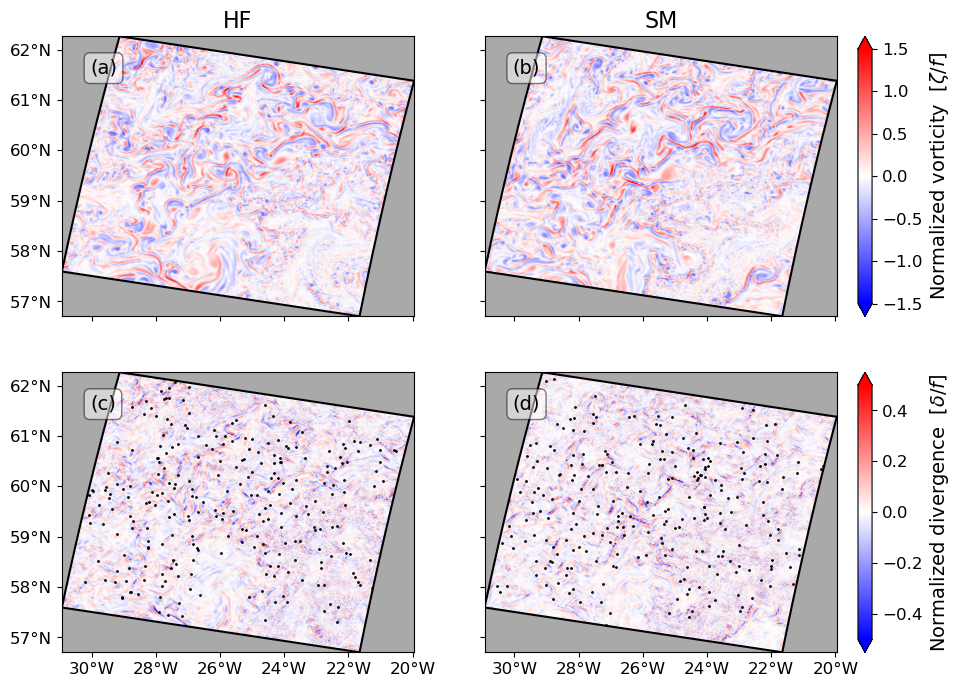

In [387]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def format_coordinate(value, coord_type='lon'):
    """
   
    """
    if coord_type == 'lon':
        if value < 0:
            return f'{abs(int(value))}°W' 
        else:
            return f'{int(value)}°E' 
    else: 
        if value < 0:
            return f'{abs(int(value))}°S'  
        else:
            return f'{int(value)}°N'  

#
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# 创建图形和子图 - 改为2x2的4个子图
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

# 定义一些常量
# pio2 = np.pi/2
# pi3o2 = np.pi*3/2
# xmin, xmax = 0, 2*np.pi  # 假设x轴范围是0到2π

# 第一个子图 (a)
ax1.set_facecolor('darkgrey')
im1 = ax1.pcolormesh(lonr, latr, Ro_w[tindex,:,:], 
                    cmap='bwr', vmin=-1.5, vmax=1.5, shading='gouraud')
# ax1.scatter(lon289_w_r[:,tindex],lat289_w_r[:,tindex],s=1,color='k')
# ax1.scatter(lon289_w_s[:,tindex],lat289_w_s[:,tindex],s=1,color='k')

ax1.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
ax1.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
ax1.set_xticklabels('')
ax1.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
ax1.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
ax1.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
ax1.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
ax1.set_title(r'HF')
ax1.text(0.08, 0.92, '(a)', transform=ax1.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 第二个子图 (b)
ax2.set_facecolor('darkgrey')
im2 = ax2.pcolormesh(lonr, latr, Ro_nw[tindex,:,:], 
                    cmap='bwr', vmin=-1.5, vmax=1.5, shading='gouraud')


ax2.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
ax2.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
ax2.set_xticklabels('')
ax2.set_yticklabels('')
ax2.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
ax2.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
ax2.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
ax2.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
ax2.set_title(r'SM')
ax2.text(0.08, 0.92, '(b)', transform=ax2.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
cax = inset_axes(ax2,
                 width="4%",
                 height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.1, 0, 1, 1),
                 bbox_transform=ax2.transAxes,
                 borderpad=0)
cbar2 = plt.colorbar(im2, cax=cax, orientation='vertical', extend='both')
cbar2.set_label(r'Normalized vorticity  [$\zeta /f$]', fontsize=14)

# 第三个子图 (c)
ax3.set_facecolor('darkgrey')
im3 = ax3.pcolormesh(lonr, latr, divof_w[tindex,:,:], 
                    cmap='bwr', vmin=-0.5, vmax=0.5, shading='gouraud')
ax3.scatter(lon289_w_r[:,tindex],lat289_w_r[:,tindex],s=1,color='k')

ax3.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
ax3.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
ax3.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
ax3.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
ax3.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
ax3.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
ax3.text(0.08, 0.92, '(c)', transform=ax3.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 第四个子图 (d)
ax4.set_facecolor('darkgrey')
im4 = ax4.pcolormesh(lonr, latr, divof_nw[tindex,:,:], 
                    cmap='bwr', vmin=-0.5, vmax=0.5, shading='gouraud')
ax4.scatter(lon289_nw_r[:,tindex],lat289_nw_r[:,tindex],s=1,color='k')

ax4.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
ax4.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
ax4.set_yticklabels('')
ax4.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
ax4.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
ax4.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
ax4.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# 
ax4.text(0.08, 0.92, '(d)', transform=ax4.transAxes, 
        fontsize=14, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 
cax = inset_axes(ax4,
                 width="4%",
                 height="100%",
                 loc='center right',
                 bbox_to_anchor=(0.1, 0, 1, 1),
                 bbox_transform=ax4.transAxes,
                 borderpad=0)
cbar = plt.colorbar(im4, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'Normalized divergence  [$\delta /f$]', fontsize=14)

# plt.tight_layout()
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig2_Iceland_vor_div_t={tindex}.png', dpi=300, bbox_inches='tight')
plt.show()

# 2.  oversamping at HF

In [285]:
colorsmap = ['#0072BD', '#D95319', '#EDB120', '#7E2F8E', '#77AC30', '#4DBEEE']

Ro_289_w_r=w289_r['Ro'].values
divof_289_w_r=w289_r['divof'].values

Ro_625_w_r=w625_r['Ro'].values
Ro_1089_w_r=w1089_r['Ro'].values

Ro_289_w_s=w289_s['Ro'].values
Ro_625_w_s=w625_s['Ro'].values
Ro_1089_w_s=w1089_s['Ro'].values

### 2.1. calc Eul/Lag Ro,divof PDF

In [279]:
bin_edges = np.arange(-1.5, 1.6, 0.1)  # 固定步长

Ro_pdf_w_e, bin_edges = np.histogram(Ro_w.ravel(), bins=bin_edges, density=True)
Ro_pdf_w_289_r, bin_edges = np.histogram(Ro_289_w_r.ravel(), bins=bin_edges, density=True)
Ro_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

In [402]:

# plt.figure(figsize=(6,4))
# plt.semilogy(Ro_bin_centers, Ro_pdf_w_e, 'k-', lw=4)
# plt.semilogy(Ro_bin_centers, Ro_pdf_w_289_r, color='#7E2F8E', lw=2)
# plt.axvline(0.1,color='k',linestyle='--')
# plt.xlim(-3,3)
# plt.ylim(1e-3,1e1)
# plt.xlabel('Value')
# plt.ylabel('PDF')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [331]:
bin_edges = np.arange(-0.8, 0.8, 0.1)  # 固定步长

divof_pdf_w_e, bin_edges = np.histogram(divof_w.ravel(), bins=bin_edges, density=True)
divof_pdf_w_289_r, bin_edges = np.histogram(divof_289_w_r.ravel(), bins=bin_edges, density=True)
divof_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

In [403]:
# plt.figure(figsize=(6,4))
# plt.semilogy(divof_bin_centers, divof_pdf_w_e, 'k-', lw=4)
# plt.semilogy(divof_bin_centers, divof_pdf_w_289_r, color='#7E2F8E', lw=2)
# # plt.axvline(0.1,color='k',linestyle='--')
# plt.xlim(-1.5,1.5)
# # plt.ylim(1e-3,1e1)
# plt.xlabel('Value')
# plt.ylabel('PDF')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [336]:
(divof_pdf_w_289_r[:8]*0.1).sum(),(divof_pdf_w_e[:8]*0.1).sum()

(0.5702356652440157, 0.48705383883528336)

### 2.2 Eul/Lag cg PDF

In [338]:
Th8_spec_w_e=np.squeeze(cgw['Th8'].values)
Th8_spec_w_289_r=w289_r['th8'].values

bin_s=5e-8
bin_edges = np.arange(-1e-6, 1e-6+bin_s, bin_s)  # 固定步长

# 计算 PDF
cg_pdf_w_e, bin_edges = np.histogram(Th8_spec_w_e.ravel(), bins=bin_edges, density=True)
cg_pdf_w_289_r, bin_edges = np.histogram(Th8_spec_w_289_r.ravel(), bins=bin_edges, density=True)

cg_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

In [404]:
# plt.figure(figsize=(6,4))
# plt.semilogy(cg_bin_centers, cg_pdf_w_e, 'k-', lw=2)
# plt.semilogy(cg_bin_centers, cg_pdf_w_289_r, 'r-', lw=2)
# # plt.plot(bin_centers, pdf_w_289_r-pdf_w_e, 'r-', lw=2)
# plt.xlim(-1.5e-6,1.5e-6)
# # plt.ylim(1e-3,1e1)
# plt.xlabel('Value')
# plt.ylabel('PDF')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

### 2.3 plot Ro, divof, CG with mask, and their PDF

In [340]:
cgw_uni=xr.open_dataset('/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_all_hf_uni.0002.nc')
Th4_w_e=cgw_uni['Th4'].values

Ro_thr=0.1
maskr_w_e=np.ones((287,287))
maskr_w_e[Ro_w[tindex,:,:]<Ro_thr]=np.nan



/tmp/ipykernel_652960/3129740728.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_map1.set_xticklabels(
/tmp/ipykernel_652960/3129740728.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_map1.set_yticklabels(
/tmp/ipykernel_652960/3129740728.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_map2.set_xticklabels(
/tmp/ipykernel_652960/3129740728.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_map2.set_yticklabels(
/tmp/ipykernel_652960/3129740728.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_map3.set_xticklabels(
/tmp/ipykernel_65296

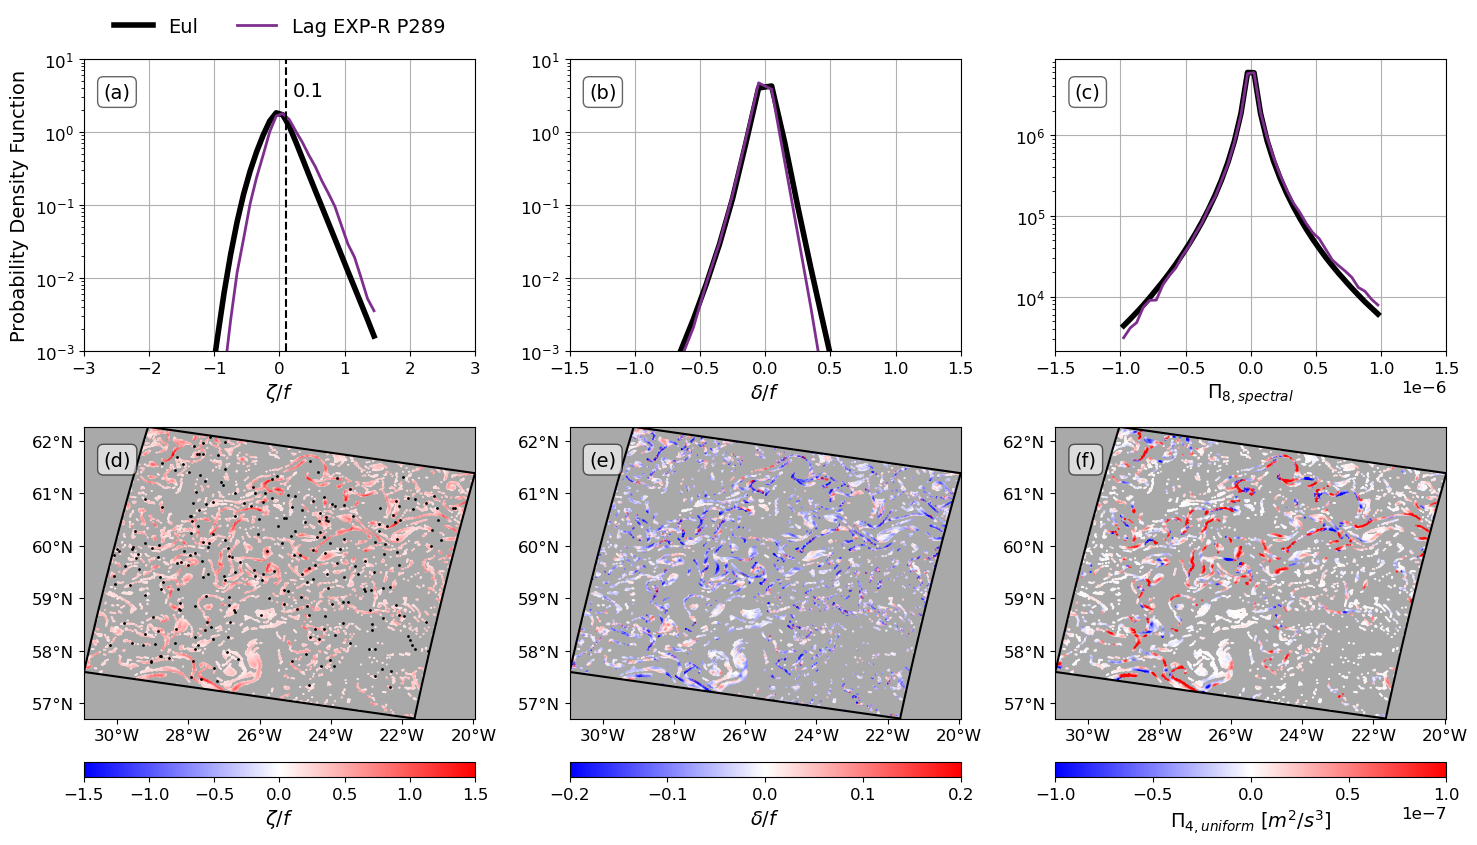

In [372]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==============================
# 字体 / 格式（完全按你原来的）
# ==============================
def format_coordinate(value, coord_type='lon'):
    """
   
    """
    if coord_type == 'lon':
        if value < 0:
            return f'{abs(int(value))}°W' 
        else:
            return f'{int(value)}°E' 
    else: 
        if value < 0:
            return f'{abs(int(value))}°S'  
        else:
            return f'{int(value)}°N'  

#
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# ==============================
# 创建 2 行 3 列子图
# ==============================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 明确命名
ax_pdf1, ax_pdf2, ax_pdf3 = axes[0]
ax_map1, ax_map2, ax_map3 = axes[1]

# ==============================
# 第一行：PDF（留空，不画任何东西）
# ==============================
for ax, title, label in zip(
    [ax_pdf1, ax_pdf2, ax_pdf3],
    [r'$\zeta/f$', r'$\delta/f$',r'$\Pi_{8,spectral}$'],
    ['(a)', '(b)', '(c)']
):
    ax.set_facecolor('none')
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_title(title)
    ax.text(0.05, 0.92, label, transform=ax.transAxes,
            fontsize=14, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))

ax_pdf1.semilogy(Ro_bin_centers, Ro_pdf_w_e, 'k-', lw=4,label='Eul')
ax_pdf1.semilogy(Ro_bin_centers, Ro_pdf_w_289_r, color='#7E2F8E', lw=2,label='Lag EXP-R P289')
ax_pdf1.axvline(0.1,color='k',linestyle='--')
ax_pdf1.set_xlim(-3,3)
ax_pdf1.set_ylim(1e-3,1e1)
ax_pdf1.set_xlabel(r'$\zeta/f$')
ax_pdf1.set_ylabel('Probability Density Function')
ax_pdf1.grid(True)
ax_pdf1.text(0.2,10**0.5,'0.1')
ax_pdf1.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
)

ax_pdf2.semilogy(divof_bin_centers, divof_pdf_w_e, 'k-', lw=4)
ax_pdf2.semilogy(divof_bin_centers, divof_pdf_w_289_r, color='#7E2F8E', lw=2)
ax_pdf2.set_xlim(-1.5,1.5)
ax_pdf2.set_ylim(1e-3,1e1)
ax_pdf2.set_xlabel(r'$\delta/f$')
ax_pdf2.grid(True)

ax_pdf3.semilogy(cg_bin_centers, cg_pdf_w_e,  'k-', lw=4)
ax_pdf3.semilogy(cg_bin_centers, cg_pdf_w_289_r, color='#7E2F8E', lw=2)
# plt.plot(bin_centers, pdf_w_289_r-pdf_w_e, 'r-', lw=2)
ax_pdf3.set_xlim(-1.5e-6,1.5e-6)
# plt.ylim(1e-3,1e1)
ax_pdf3.set_xlabel(r'$\Pi_{8,spectral}$')
ax_pdf3.grid(True)
# ==============================
# 第二行：pcolormesh（完全按你原来的写法）
# ==============================
# (d) Ro
ax_map1.set_facecolor('darkgrey')
im1 = ax_map1.pcolormesh(
    lonr, latr,
    Ro_w[tindex, :, :] * maskr_w_e,
    cmap='bwr', vmin=-1.5, vmax=1.5,
    shading='gouraud'
)
ax_map1.scatter(lon289_w_r[:,tindex],lat289_w_r[:,tindex],s=1,color='k')
ax_map1.plot(lonr[:, 0], latr[:, 0], 'k-', lw=1.5)
ax_map1.plot(lonr[:, -1], latr[:, -1], 'k-', lw=1.5)
ax_map1.plot(lonr[0, :], latr[0, :], 'k-', lw=1.5)
ax_map1.plot(lonr[-1, :], latr[-1, :], 'k-', lw=1.5)
# ax_map1.set_title('Ro')
ax_map1.text(0.05, 0.92, '(d)', transform=ax_map1.transAxes,
             fontsize=14, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
ax_map1.set_xticklabels(
    [format_coordinate(x, 'lon') for x in ax_map1.get_xticks()]
)
ax_map1.set_yticklabels(
    [format_coordinate(y, 'lat') for y in ax_map1.get_yticks()]
)
# (e) divergence
ax_map2.set_facecolor('darkgrey')
im2 = ax_map2.pcolormesh(
    lonr, latr,
    divof_w[tindex, :, :] * maskr_w_e,
    cmap='bwr', vmin=-0.2, vmax=0.2,
    shading='gouraud'
)
ax_map2.plot(lonr[:, 0], latr[:, 0], 'k-', lw=1.5)
ax_map2.plot(lonr[:, -1], latr[:, -1], 'k-', lw=1.5)
ax_map2.plot(lonr[0, :], latr[0, :], 'k-', lw=1.5)
ax_map2.plot(lonr[-1, :], latr[-1, :], 'k-', lw=1.5)
# ax_map2.set_title(r'$\delta/f$')
ax_map2.text(0.05, 0.92, '(e)', transform=ax_map2.transAxes,
             fontsize=14, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
ax_map2.set_xticklabels(
    [format_coordinate(x, 'lon') for x in ax_map1.get_xticks()]
)
ax_map2.set_yticklabels(
    [format_coordinate(y, 'lat') for y in ax_map1.get_yticks()]
)
# (f) cg 4*2
ax_map3.set_facecolor('darkgrey')
im3 = ax_map3.pcolormesh(
    lonr, latr,
    np.squeeze(Th4_w_e)[tindex, :, :] * maskr_w_e,
    cmap='bwr', vmin=-1e-7, vmax=1e-7,
    shading='gouraud'
)
ax_map3.plot(lonr[:, 0], latr[:, 0], 'k-', lw=1.5)
ax_map3.plot(lonr[:, -1], latr[:, -1], 'k-', lw=1.5)
ax_map3.plot(lonr[0, :], latr[0, :], 'k-', lw=1.5)
ax_map3.plot(lonr[-1, :], latr[-1, :], 'k-', lw=1.5)
# ax_map3.set_title(r'$\zeta/f$')
ax_map3.text(0.05, 0.92, '(f)', transform=ax_map3.transAxes,
             fontsize=14, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
ax_map3.set_xticklabels(
    [format_coordinate(x, 'lon') for x in ax_map1.get_xticks()]
)
ax_map3.set_yticklabels(
    [format_coordinate(y, 'lat') for y in ax_map1.get_yticks()]
)
# ==============================
# 底部 colorbar（全部横向放在最下面）
# ==============================
cax1 = inset_axes(ax_map1,
                  width="100%", height="5%",
                  loc='lower center',
                  borderpad=-3)
cb1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cb1.set_label(r'$\zeta/f$')

cax2 = inset_axes(ax_map2,
                  width="100%", height="5%",
                  loc='lower center',
                  borderpad=-3)
cb2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
cb2.set_label(r'$\delta/f$')

cax3 = inset_axes(ax_map3,
                  width="100%", height="5%",
                  loc='lower center',
                  borderpad=-3)
cb3 = plt.colorbar(im3, cax=cax3, orientation='horizontal')
cb3.set_label(r'$\Pi_{4,uniform} \ [m^{2}/s^{3}]$')

# ==============================
# 收紧布局（不压 colorbar）
# ==============================
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/FigB_HF_oversampling_t={tindex}.png', dpi=300, bbox_inches='tight')

plt.show()

# 3. oversampling in Sm

In [396]:
Ro_289_nw_r=nw289_r['Ro'].values
divof_289_nw_r=nw289_r['divof'].values
bin_edges = np.arange(-1.5, 1.6, 0.1)  # 固定步长

Ro_pdf_nw_e, bin_edges = np.histogram(Ro_nw.ravel(), bins=bin_edges, density=True)
Ro_pdf_nw_289_r, bin_edges = np.histogram(Ro_289_nw_r.ravel(), bins=bin_edges, density=True)
Ro_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bin_edges = np.arange(-0.8, 0.8, 0.1)  # 固定步长

divof_pdf_nw_e, bin_edges = np.histogram(divof_nw.ravel(), bins=bin_edges, density=True)
divof_pdf_nw_289_r, bin_edges = np.histogram(divof_289_nw_r.ravel(), bins=bin_edges, density=True)
divof_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

Th8_spec_nw_e=np.squeeze(cgnw['Th6'].values)
Th8_spec_nw_289_r=nw289_r['th6'].values

bin_s=5e-8
bin_edges = np.arange(-1e-6, 1e-6+bin_s, bin_s)  # 固定步长

# 计算 PDF
cg_pdf_nw_e, bin_edges = np.histogram(Th8_spec_nw_e.ravel(), bins=bin_edges, density=True)
cg_pdf_nw_289_r, bin_edges = np.histogram(Th8_spec_nw_289_r.ravel(), bins=bin_edges, density=True)

cg_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

In [397]:
cgnw_uni=xr.open_dataset('/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_all_smooth_uni.0002.nc')
Th4_nw_e=cgnw_uni['Th3'].values

Ro_thr=0.1
maskr_w_e=np.ones((287,287))
maskr_w_e[Ro_nw[tindex,:,:]<Ro_thr]=np.nan

/tmp/ipykernel_652960/2839043509.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_map1.set_xticklabels(
/tmp/ipykernel_652960/2839043509.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_map1.set_yticklabels(
/tmp/ipykernel_652960/2839043509.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_map2.set_xticklabels(
/tmp/ipykernel_652960/2839043509.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_map2.set_yticklabels(
/tmp/ipykernel_652960/2839043509.py:151: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_map3.set_xticklabels(
/tmp/ipykernel_65296

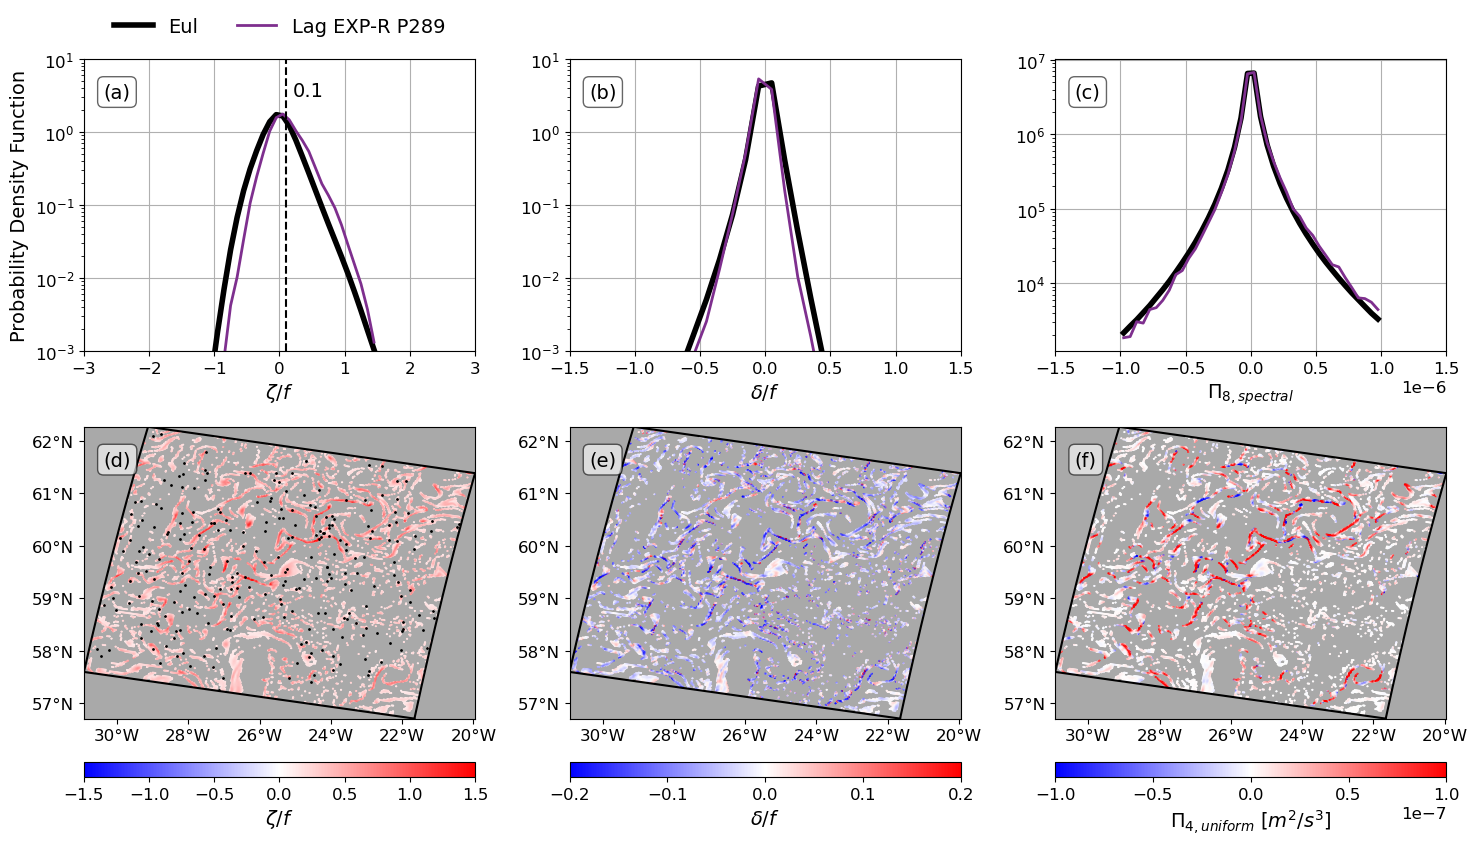

In [398]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==============================
# 字体 / 格式（完全按你原来的）
# ==============================
def format_coordinate(value, coord_type='lon'):
    """
   
    """
    if coord_type == 'lon':
        if value < 0:
            return f'{abs(int(value))}°W' 
        else:
            return f'{int(value)}°E' 
    else: 
        if value < 0:
            return f'{abs(int(value))}°S'  
        else:
            return f'{int(value)}°N'  

#
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

# ==============================
# 创建 2 行 3 列子图
# ==============================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 明确命名
ax_pdf1, ax_pdf2, ax_pdf3 = axes[0]
ax_map1, ax_map2, ax_map3 = axes[1]

# ==============================
# 第一行：PDF（留空，不画任何东西）
# ==============================
for ax, title, label in zip(
    [ax_pdf1, ax_pdf2, ax_pdf3],
    [r'$\zeta/f$', r'$\delta/f$',r'$\Pi_{8,spectral}$'],
    ['(a)', '(b)', '(c)']
):
    ax.set_facecolor('none')
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_title(title)
    ax.text(0.05, 0.92, label, transform=ax.transAxes,
            fontsize=14, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))

ax_pdf1.semilogy(Ro_bin_centers, Ro_pdf_nw_e, 'k-', lw=4,label='Eul')
ax_pdf1.semilogy(Ro_bin_centers, Ro_pdf_nw_289_r, color='#7E2F8E', lw=2,label='Lag EXP-R P289')
ax_pdf1.axvline(0.1,color='k',linestyle='--')
ax_pdf1.set_xlim(-3,3)
ax_pdf1.set_ylim(1e-3,1e1)
ax_pdf1.set_xlabel(r'$\zeta/f$')
ax_pdf1.set_ylabel('Probability Density Function')
ax_pdf1.grid(True)
ax_pdf1.text(0.2,10**0.5,'0.1')
ax_pdf1.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
)

ax_pdf2.semilogy(divof_bin_centers, divof_pdf_nw_e, 'k-', lw=4)
ax_pdf2.semilogy(divof_bin_centers, divof_pdf_nw_289_r, color='#7E2F8E', lw=2)
ax_pdf2.set_xlim(-1.5,1.5)
ax_pdf2.set_ylim(1e-3,1e1)
ax_pdf2.set_xlabel(r'$\delta/f$')
ax_pdf2.grid(True)

ax_pdf3.semilogy(cg_bin_centers, cg_pdf_nw_e,  'k-', lw=4)
ax_pdf3.semilogy(cg_bin_centers, cg_pdf_nw_289_r, color='#7E2F8E', lw=2)
# plt.plot(bin_centers, pdf_w_289_r-pdf_w_e, 'r-', lw=2)
ax_pdf3.set_xlim(-1.5e-6,1.5e-6)
# plt.ylim(1e-3,1e1)
ax_pdf3.set_xlabel(r'$\Pi_{8,spectral}$')
ax_pdf3.grid(True)
# ==============================
# 第二行：pcolormesh（完全按你原来的写法）
# ==============================
# (d) Ro
ax_map1.set_facecolor('darkgrey')
im1 = ax_map1.pcolormesh(
    lonr, latr,
    Ro_nw[tindex, :, :] * maskr_w_e,
    cmap='bwr', vmin=-1.5, vmax=1.5,
    shading='gouraud'
)
ax_map1.scatter(lon289_nw_r[:,tindex],lat289_nw_r[:,tindex],s=1,color='k')
ax_map1.plot(lonr[:, 0], latr[:, 0], 'k-', lw=1.5)
ax_map1.plot(lonr[:, -1], latr[:, -1], 'k-', lw=1.5)
ax_map1.plot(lonr[0, :], latr[0, :], 'k-', lw=1.5)
ax_map1.plot(lonr[-1, :], latr[-1, :], 'k-', lw=1.5)
# ax_map1.set_title('Ro')
ax_map1.text(0.05, 0.92, '(d)', transform=ax_map1.transAxes,
             fontsize=14, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
ax_map1.set_xticklabels(
    [format_coordinate(x, 'lon') for x in ax_map1.get_xticks()]
)
ax_map1.set_yticklabels(
    [format_coordinate(y, 'lat') for y in ax_map1.get_yticks()]
)
# (e) divergence
ax_map2.set_facecolor('darkgrey')
im2 = ax_map2.pcolormesh(
    lonr, latr,
    divof_nw[tindex, :, :] * maskr_w_e,
    cmap='bwr', vmin=-0.2, vmax=0.2,
    shading='gouraud'
)
ax_map2.plot(lonr[:, 0], latr[:, 0], 'k-', lw=1.5)
ax_map2.plot(lonr[:, -1], latr[:, -1], 'k-', lw=1.5)
ax_map2.plot(lonr[0, :], latr[0, :], 'k-', lw=1.5)
ax_map2.plot(lonr[-1, :], latr[-1, :], 'k-', lw=1.5)
# ax_map2.set_title(r'$\delta/f$')
ax_map2.text(0.05, 0.92, '(e)', transform=ax_map2.transAxes,
             fontsize=14, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
ax_map2.set_xticklabels(
    [format_coordinate(x, 'lon') for x in ax_map1.get_xticks()]
)
ax_map2.set_yticklabels(
    [format_coordinate(y, 'lat') for y in ax_map1.get_yticks()]
)
# (f) cg 4*2
ax_map3.set_facecolor('darkgrey')
im3 = ax_map3.pcolormesh(
    lonr, latr,
    np.squeeze(Th4_nw_e)[tindex, :, :] * maskr_w_e,
    cmap='bwr', vmin=-1e-7, vmax=1e-7,
    shading='gouraud'
)
ax_map3.plot(lonr[:, 0], latr[:, 0], 'k-', lw=1.5)
ax_map3.plot(lonr[:, -1], latr[:, -1], 'k-', lw=1.5)
ax_map3.plot(lonr[0, :], latr[0, :], 'k-', lw=1.5)
ax_map3.plot(lonr[-1, :], latr[-1, :], 'k-', lw=1.5)
# ax_map3.set_title(r'$\zeta/f$')
ax_map3.text(0.05, 0.92, '(f)', transform=ax_map3.transAxes,
             fontsize=14, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
ax_map3.set_xticklabels(
    [format_coordinate(x, 'lon') for x in ax_map1.get_xticks()]
)
ax_map3.set_yticklabels(
    [format_coordinate(y, 'lat') for y in ax_map1.get_yticks()]
)
# ==============================
# 底部 colorbar（全部横向放在最下面）
# ==============================
cax1 = inset_axes(ax_map1,
                  width="100%", height="5%",
                  loc='lower center',
                  borderpad=-3)
cb1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cb1.set_label(r'$\zeta/f$')

cax2 = inset_axes(ax_map2,
                  width="100%", height="5%",
                  loc='lower center',
                  borderpad=-3)
cb2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
cb2.set_label(r'$\delta/f$')

cax3 = inset_axes(ax_map3,
                  width="100%", height="5%",
                  loc='lower center',
                  borderpad=-3)
cb3 = plt.colorbar(im3, cax=cax3, orientation='horizontal')
cb3.set_label(r'$\Pi_{4,uniform} \ [m^{2}/s^{3}]$')

# ==============================
# 收紧布局（不压 colorbar）
# ==============================
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/FigB_SM_oversampling_t={tindex}.png', dpi=300, bbox_inches='tight')

plt.show()

# uniform sampling in 2D turbulence

In [510]:
cgh=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin_withRo.nc')
ds=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/HIT2d_pars_P62500T20.0seconds_withRo.nc')
cgh

<xarray.Dataset> Size: 15GB
Dimensions:     (time: 199, xi_rho: 512, eta_rho: 512, xi_u: 511, eta_v: 511,
                 depth: 1, depth_2: 1)
Coordinates:
  * time        (time) float64 2kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * xi_rho      (xi_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 509.0 510.0 511.0 512.0
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 510.0 511.0 512.0
  * xi_u        (xi_u) float64 4kB 1.0 2.0 3.0 4.0 ... 508.0 509.0 510.0 511.0
  * eta_v       (eta_v) float64 4kB 1.0 2.0 3.0 4.0 ... 508.0 509.0 510.0 511.0
  * depth       (depth) float64 8B -2.0
Dimensions without coordinates: depth_2
Data variables: (12/72)
    u_rho       (time, depth, eta_rho, xi_rho) float64 417MB ...
    v_rho       (time, depth, eta_rho, xi_rho) float64 417MB ...
    u           (time, depth, eta_rho, xi_u) float64 417MB ...
    v           (time, depth, eta_v, xi_rho) float64 417MB ...
    ocean_time  (time) float64 2kB ...
    lon_rho     (eta_rho, xi_rho) float64 2MB ...
    ...          ...
    Th432       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
    Th456       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
    Th480       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
    Th504       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
    Th512       (time, depth_2, eta_rho, xi_rho) float32 209MB ...
    vor         (time, eta_rho, xi_rho) float64 417MB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Oct 24 15:07:18 2025: cdo merge ../Parcels_data/HIT2d_n...
    CDO:          Climate Data Operators version 2.4.1 (https://mpimet.mpg.de...

In [530]:
lonr=cgh['lon_rho'].values
latr=cgh['lat_rho'].values

In [512]:
u1=u2rho_3d(np.squeeze(cgh['u'].values))
v1=v2rho_3d(np.squeeze(cgh['v'].values))
dx=1/512*2*np.pi
dy=dx
ux=u2rho_3d(u1[:,:,1:]-u1[:,:,:-1])/dx
vx=u2rho_3d(v1[:,:,1:]-v1[:,:,:-1])/dx
uy=v2rho_3d(u1[:,1:,:]-u1[:,:-1,:])/dy
vy=v2rho_3d(v1[:,1:,:]-v1[:,:-1,:])/dy
vor=(vx-uy)/100

In [513]:
vor1=vor[50:150,:,:]

In [514]:
vor_lag=ds['vor'].values[:,50:150]/100

In [515]:
bin_edges = np.arange(-20, 21, 1)  # 固定步长

Ro_pdf_hit_e, bin_edges = np.histogram(vor1.ravel(), bins=bin_edges, density=True)
Ro_pdf_hit_l, bin_edges = np.histogram(vor_lag.ravel(), bins=bin_edges, density=True)
Ro_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

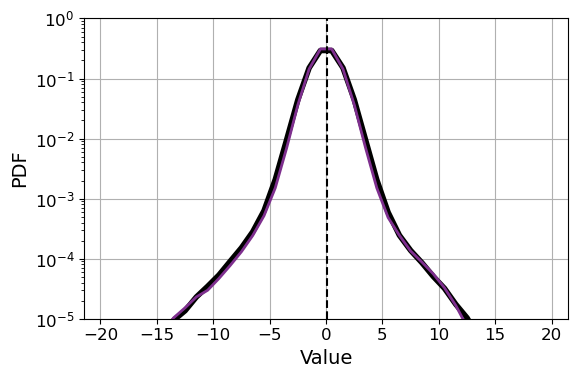

In [516]:
plt.figure(figsize=(6,4))
plt.semilogy(Ro_bin_centers, Ro_pdf_hit_e, 'k-', lw=4)
plt.semilogy(Ro_bin_centers, Ro_pdf_hit_l, color='#7E2F8E', lw=2)
plt.axvline(0.1,color='k',linestyle='--')
# plt.xlim(-3,3)
plt.ylim(1e-5,1e0)
plt.xlabel('Value')
plt.ylabel('PDF')
plt.grid(True)
plt.tight_layout()
plt.show()

In [517]:
Th6=(np.squeeze(cgh['Th6'].values[50:150,:,:,:]))
Th6_l=(np.squeeze(ds['th6'].values[:,50:150]))


bin_edges = np.arange(-2000, 2010, 10)  # 固定步长

cg_pdf_hit_e, bin_edges = np.histogram(Th6.ravel(), bins=bin_edges, density=True)
cg_pdf_hit_l, bin_edges = np.histogram(Th6_l.ravel(), bins=bin_edges, density=True)

cg_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

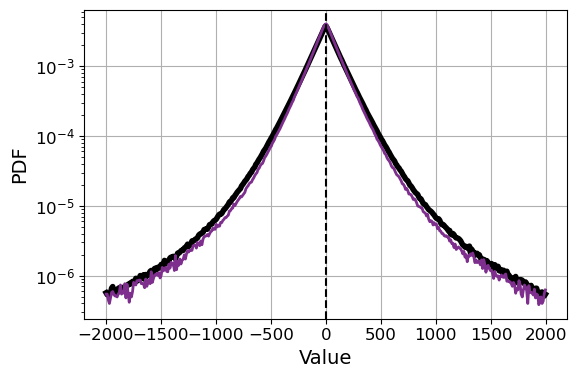

In [518]:
plt.figure(figsize=(6,4))
plt.semilogy(cg_bin_centers, cg_pdf_hit_e, 'k-', lw=4)
plt.semilogy(cg_bin_centers, cg_pdf_hit_l, color='#7E2F8E', lw=2)
plt.axvline(0,color='k',linestyle='--')
# plt.xlim(-3,3)
# plt.ylim(1e-5,1e0)
plt.xlabel('Value')
plt.ylabel('PDF')
plt.grid(True)
plt.tight_layout()
plt.show()

In [519]:
tindex=100

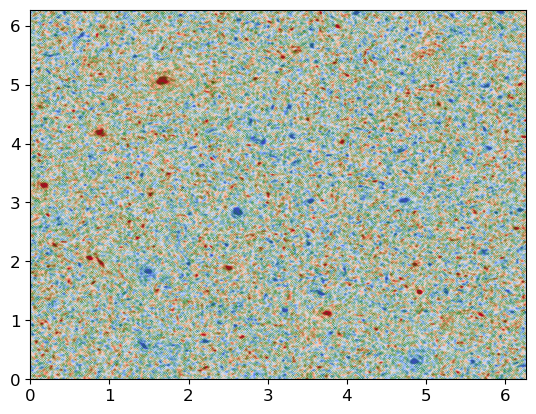

In [520]:
plt.pcolormesh(lonr,latr,np.squeeze(vor)[tindex,:,:],cmap='coolwarm',vmin=-4,vmax=4,shading='gouraud')
ds['vor'].values[:,50:150]/100
plt.scatter(ds['lon'].values[:,tindex],ds['lat'].values[:,tindex],s=0.01,color='g')

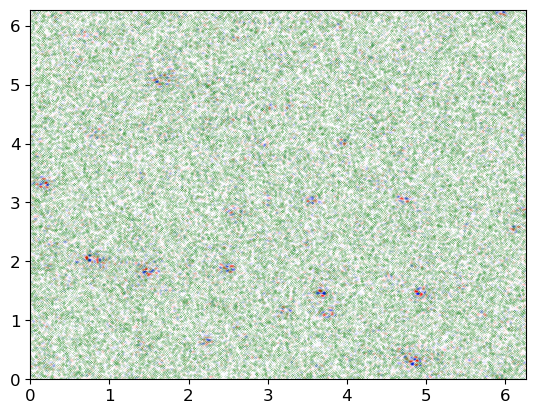

In [521]:
plt.pcolormesh(lonr,latr,(np.squeeze(cgh['Th6'].values[tindex,:,:,:])),cmap='bwr',vmin=-3000,vmax=3000,shading='gouraud')
plt.scatter(ds['lon'].values[:,tindex],ds['lat'].values[:,tindex],s=0.01,color='g')

In [522]:
6.28/64,6*0.0123

(0.098125, 0.0738)

/tmp/ipykernel_652960/2786725171.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


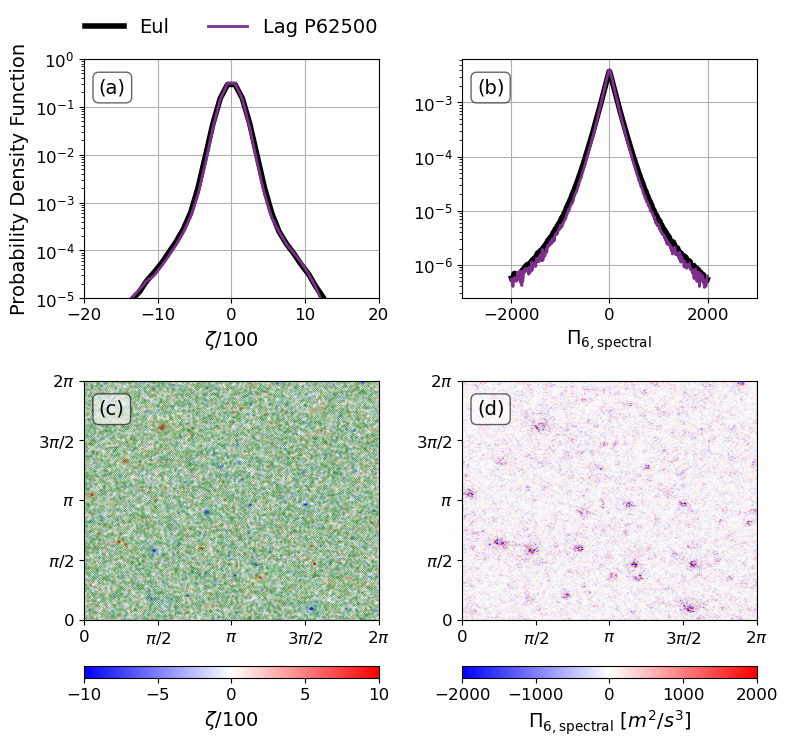

In [543]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==============================
# 字体 / 格式（完全按你原来的）
# ==============================
def format_coordinate(value, coord_type='lon'):
    if coord_type == 'lon':
        return f'{abs(int(value))}°W' if value < 0 else f'{int(value)}°E'
    else:
        return f'{abs(int(value))}°S' if value < 0 else f'{int(value)}°N'

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})
xmin, xmax=0,2*np.pi
# ==============================
# 创建 2×2 子图
# ==============================
fig, axes = plt.subplots(2, 2, figsize=(8, 7))

ax_pdf1, ax_pdf2 = axes[0]
ax_map1, ax_map2 = axes[1]

# ==============================
# 第一行：PDF
# ==============================
for ax, title, label in zip(
    [ax_pdf1, ax_pdf2],
    [r'$\zeta/f$', r'$\Pi_{8,\mathrm{spectral}}$'],
    ['(a)', '(b)']
):
    ax.set_facecolor('none')
    ax.text(0.05, 0.92, label, transform=ax.transAxes,
            fontsize=14, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))

# (a) ζ/f PDF
ax_pdf1.semilogy(Ro_bin_centers, Ro_pdf_hit_e, 'k-', lw=4, label='Eul')
ax_pdf1.semilogy(Ro_bin_centers, Ro_pdf_hit_l, color='#7E2F8E', lw=2,
                label='Lag P62500')
# ax_pdf1.axvline(0.1, color='k', linestyle='--')
ax_pdf1.set_xlim(-20, 20)
ax_pdf1.set_ylim(1e-5, 1e0)
ax_pdf1.set_xlabel(r'$\zeta/100$')
ax_pdf1.set_ylabel('Probability Density Function')
ax_pdf1.grid(True)
ax_pdf1.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02),
               ncol=2, frameon=False)

# (b) Π₈ PDF
ax_pdf2.semilogy(cg_bin_centers, cg_pdf_hit_e, 'k-', lw=4)
ax_pdf2.semilogy(cg_bin_centers, cg_pdf_hit_l, color='#7E2F8E', lw=2)
ax_pdf2.set_xlim(-3000, 3000)
ax_pdf2.set_xlabel(r'$\Pi_{6,\mathrm{spectral}}$')
ax_pdf2.grid(True)

# ==============================
# 第二行：pcolormesh
# ==============================
# (c) Ro
ax_map1.set_facecolor('darkgrey')
im1 = ax_map1.pcolormesh(
    lonr, latr,
    np.squeeze(vor)[tindex,:,:] ,
    cmap='bwr', vmin=-10, vmax=10,
    shading='gouraud'
)

ax_map1.scatter(ds['lon'].values[:,tindex],ds['lat'].values[:,tindex],s=0.005,color='g')
# ax_map1.plot(lonr[:, 0], latr[:, 0], 'k-', lw=1.5)
# ax_map1.plot(lonr[:, -1], latr[:, -1], 'k-', lw=1.5)
# ax_map1.plot(lonr[0, :], latr[0, :], 'k-', lw=1.5)
# ax_map1.plot(lonr[-1, :], latr[-1, :], 'k-', lw=1.5)
ax_map1.text(0.05, 0.92, '(c)', transform=ax_map1.transAxes,
             fontsize=14, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
ax_map1.set_xlim(xmin, xmax)
ax_map1.set_ylim(xmin, xmax)

ax_map1.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax_map1.set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax_map1.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax_map1.set_yticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
# ax_map1.set_xticklabels(
#     [format_coordinate(x, 'lon') for x in ax_map1.get_xticks()]
# )
# ax_map1.set_yticklabels(
#     [format_coordinate(y, 'lat') for y in ax_map1.get_yticks()]
# )

# (d) ζ/f
ax_map2.set_facecolor('darkgrey')
im2 = ax_map2.pcolormesh(
    lonr,latr,(np.squeeze(cgh['Th6'].values[tindex,:,:,:])),cmap='bwr',vmin=-2000,vmax=2000,
    shading='gouraud'
)
# ax_map2.plot(lonr[:, 0], latr[:, 0], 'k-', lw=1.5)
# ax_map2.plot(lonr[:, -1], latr[:, -1], 'k-', lw=1.5)
# ax_map2.plot(lonr[0, :], latr[0, :], 'k-', lw=1.5)
# ax_map2.plot(lonr[-1, :], latr[-1, :], 'k-', lw=1.5)
ax_map2.text(0.05, 0.92, '(d)', transform=ax_map2.transAxes,
             fontsize=14, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
# ax_map2.set_xticklabels(
#     [format_coordinate(x, 'lon') for x in ax_map1.get_xticks()]
# )
# ax_map2.set_yticklabels(
#     [format_coordinate(y, 'lat') for y in ax_map1.get_yticks()]
# )

# ==============================
# 底部 colorbar（独立、横向）
# ==============================
cax1 = inset_axes(ax_map1, width="100%", height="5%",
                  loc='lower center', borderpad=-3)
cb1 = plt.colorbar(im1, cax=cax1, orientation='horizontal')
cb1.set_label(r'$\zeta/100$')

cax2 = inset_axes(ax_map2, width="100%", height="5%",
                  loc='lower center', borderpad=-3)
cb2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
cb2.set_label(r'$\Pi_{6,\mathrm{spectral}} \ [m^{2}/s^{3}]$')

ax_map2.set_xlim(xmin, xmax)
ax_map2.set_ylim(xmin, xmax)

ax_map2.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax_map2.set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax_map2.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax_map2.set_yticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])


# ==============================
# 收紧布局
# ==============================
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(
    f'/meddy/simingzhang/Data/Figure_SF3/FigB_HIT_2x2_t={tindex}.png',
    dpi=300, bbox_inches='tight'
)
plt.show()

# hotpoint

In [7]:
KE_w=u2rho_3d(np.squeeze(cgw['u'].values))**2+v2rho_3d(np.squeeze(cgw['v'].values))**2

In [8]:
# heatmap = create_particle_heatmap(lon289_w_s, lonr,latr,lat289_w_s)
# density, total_count, time_count = create_particle_density(lon289_w_r, lonr, latr, lat289_w_r)
# pdf289w_r_1mon, total_obs = create_particle_pdf(lon289_w_r_1mon, lonr, latr, lat289_w_r_1mon)
# pdf625w_r_1mon, total_obs = create_particle_pdf(lon625_w_r_1mon, lonr, latr, lat625_w_r_1mon)
# pdf1089w_r_1mon, total_obs = create_particle_pdf(lon1089_w_r_1mon, lonr, latr, lat1089_w_r_1mon)

# pdf289w_r_2mon, total_obs = create_particle_pdf(lon289_w_r_2mon, lonr, latr, lat289_w_r_2mon)
# pdf625w_r_2mon, total_obs = create_particle_pdf(lon625_w_r_2mon, lonr, latr, lat625_w_r_2mon)
# pdf1089w_r_2mon, total_obs = create_particle_pdf(lon1089_w_r_2mon, lonr, latr, lat1089_w_r_2mon)

pdf289w_r, total_obs = create_particle_pdf(lon289_w_r, lonr, latr, lat289_w_r)
pdf625w_r, total_obs = create_particle_pdf(lon625_w_r, lonr, latr, lat625_w_r)
pdf1089w_r, total_obs = create_particle_pdf(lon1089_w_r, lonr, latr, lat1089_w_r)

pdf289nw_r, total_obs = create_particle_pdf(lon289_nw_r, lonr, latr, lat289_nw_r)
pdf625nw_r, total_obs = create_particle_pdf(lon625_nw_r, lonr, latr, lat625_nw_r)
pdf1089nw_r, total_obs = create_particle_pdf(lon1089_nw_r, lonr, latr, lat1089_nw_r)

pdf289w_s, total_obs = create_particle_pdf(lon289_w_s, lonr, latr, lat289_w_s)
pdf625w_s, total_obs = create_particle_pdf(lon625_w_s, lonr, latr, lat625_w_s)
pdf1089w_s, total_obs = create_particle_pdf(lon1089_w_s, lonr, latr, lat1089_w_s)

pdf289nw_s, total_obs = create_particle_pdf(lon289_nw_s, lonr, latr, lat289_nw_s)
pdf625nw_s, total_obs = create_particle_pdf(lon625_nw_s, lonr, latr, lat625_nw_s)
pdf1089nw_s, total_obs = create_particle_pdf(lon1089_nw_s, lonr, latr, lat1089_nw_s)

计算粒子PDF，289 个粒子，2148 个时间步...
PDF总和: 1.000000
总粒子观测次数: 323343
计算粒子PDF，625 个粒子，2149 个时间步...
PDF总和: 1.000000
总粒子观测次数: 679503
计算粒子PDF，1089 个粒子，2148 个时间步...
PDF总和: 1.000000
总粒子观测次数: 1241971
计算粒子PDF，289 个粒子，2148 个时间步...
PDF总和: 1.000000
总粒子观测次数: 302294
计算粒子PDF，625 个粒子，2148 个时间步...
PDF总和: 1.000000
总粒子观测次数: 669646
计算粒子PDF，1089 个粒子，2148 个时间步...
PDF总和: 1.000000
总粒子观测次数: 1144189
计算粒子PDF，289 个粒子，2148 个时间步...
PDF总和: 1.000000
总粒子观测次数: 450812
计算粒子PDF，625 个粒子，2148 个时间步...
PDF总和: 1.000000
总粒子观测次数: 985485
计算粒子PDF，1089 个粒子，2149 个时间步...
PDF总和: 1.000000
总粒子观测次数: 1727024
计算粒子PDF，289 个粒子，2148 个时间步...
PDF总和: 1.000000
总粒子观测次数: 474034
计算粒子PDF，625 个粒子，2148 个时间步...
PDF总和: 1.000000
总粒子观测次数: 1034891
计算粒子PDF，1089 个粒子，2148 个时间步...
PDF总和: 1.000000
总粒子观测次数: 1786580


In [9]:
# from cmocean import cm
# import matplotlib.colors as colors
# def format_coordinate(value, coord_type='lon'):
#     """
   
#     """
#     if coord_type == 'lon':
#         if value < 0:
#             return f'{abs(int(value))}°W' 
#         else:
#             return f'{int(value)}°E' 
#     else: 
#         if value < 0:
#             return f'{abs(int(value))}°S'  
#         else:
#             return f'{int(value)}°N'  
            
# plt.rcParams.update({
#     'font.size': 14,
#     'axes.titlesize': 16,
#     'axes.labelsize': 14,
#     'xtick.labelsize': 12,
#     'ytick.labelsize': 12,
# })

# # 创建图形和子图 - 改为2x2的4个子图
# fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))



# ax1.set_facecolor('darkgrey')
# mesh = ax1.pcolormesh(lonr, latr, pdf289w, cmap=cm.thermal,
#                      vmin=0,vmax=0.00010)
# plt.colorbar(mesh, label='Particle Density ')
# ax1.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# ax1.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# ax1.set_yticklabels('')
# ax1.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# ax1.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# ax1.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# ax1.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# ax2.set_facecolor('darkgrey')
# # mesh = ax2.pcolormesh(lonr, latr, np.log(np.nanmean(KE_w,axis=0)),cmap='jet')
# # plt.colorbar(mesh, label='Particle Density ')
# mesh = ax2.pcolormesh(lonr, latr, np.squeeze((np.nanmean(Th4w,axis=0))),cmap=cm.balance,vmin=-1e-7,vmax=1e-7)
# plt.colorbar(mesh, label='Particle Density ')
# ax2.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# ax2.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# ax2.set_yticklabels('')
# ax2.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# ax2.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# ax2.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# ax2.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# ax3.set_facecolor('darkgrey')
# mesh = ax3.pcolormesh(lonr, latr, pdf625w, cmap=cm.thermal,
#                      vmin=0,vmax=0.00010)
# plt.colorbar(mesh, label='Particle Density ')
# ax3.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# ax3.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# ax3.set_yticklabels('')
# ax3.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# ax3.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# ax3.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# ax3.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# ax4.set_facecolor('darkgrey')
# mesh = ax4.pcolormesh(lonr, latr, pdf1089w, cmap=cm.thermal,
#                      vmin=0,vmax=0.00010)
# plt.colorbar(mesh, label='Particle Density ')
# ax4.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# ax4.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# ax4.set_yticklabels('')
# ax4.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# ax4.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# ax4.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# ax4.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

In [10]:
# heatmap.shape,density.shape,Th5w.shape

In [11]:
# np.max(density)

In [544]:
# from cmocean import cm
# import matplotlib.colors as colors
# def format_coordinate(value, coord_type='lon'):
#     """
   
#     """
#     if coord_type == 'lon':
#         if value < 0:
#             return f'{abs(int(value))}°W' 
#         else:
#             return f'{int(value)}°E' 
#     else: 
#         if value < 0:
#             return f'{abs(int(value))}°S'  
#         else:
#             return f'{int(value)}°N'  
            
# plt.rcParams.update({
#     'font.size': 14,
#     'axes.titlesize': 16,
#     'axes.labelsize': 14,
#     'xtick.labelsize': 12,
#     'ytick.labelsize': 12,
# })

# # 创建图形和子图 - 改为2x2的4个子图
# fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(18, 8))
# pdfmax=0.00005
# cgmax=5e-8

# axx=ax1
# axx.set_facecolor('darkgrey')
# mesh = axx.pcolormesh(lonr, latr, pdf289w_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# # plt.colorbar(mesh, label='Particle Density ')
# axx.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# axx.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# axx.set_yticklabels('')
# axx.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# axx=ax2
# axx.set_facecolor('darkgrey')
# mesh = axx.pcolormesh(lonr, latr, pdf625w_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# # plt.colorbar(mesh, label='Particle Density ')
# axx.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# axx.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# axx.set_yticklabels('')
# axx.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# axx=ax3
# axx.set_facecolor('darkgrey')
# mesh = axx.pcolormesh(lonr, latr, pdf1089w_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# # plt.colorbar(mesh, label='Particle Density ')
# axx.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# axx.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# axx.set_yticklabels('')
# axx.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# axx=ax4
# axx.set_facecolor('darkgrey')
# mesh = axx.pcolormesh(lonr, latr, np.squeeze((np.nanmean(Th4w,axis=0))),cmap=cm.balance,vmin=-cgmax,vmax=cgmax)
# # plt.colorbar(mesh, label='Particle Density ')
# axx.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# axx.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# axx.set_yticklabels('')
# axx.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
# ###############################################################################nw
# axx=ax5
# axx.set_facecolor('darkgrey')
# mesh = axx.pcolormesh(lonr, latr, pdf289nw_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# # plt.colorbar(mesh, label='Particle Density ')
# axx.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# axx.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# axx.set_yticklabels('')
# axx.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# axx=ax6
# axx.set_facecolor('darkgrey')
# mesh = axx.pcolormesh(lonr, latr, pdf625nw_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# # plt.colorbar(mesh, label='Particle Density ')
# axx.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# axx.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# axx.set_yticklabels('')
# axx.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# axx=ax7
# axx.set_facecolor('darkgrey')
# mesh = axx.pcolormesh(lonr, latr, pdf1089nw_s, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# # plt.colorbar(mesh, label='Particle Density ')
# axx.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# axx.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# axx.set_yticklabels('')
# axx.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

# lay=20
# axx.plot(lonr[:,lay], latr[:,lay], color='r', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-lay], latr[:,-lay], color='r', linestyle='-',linewidth=1.5)
# axx.plot(lonr[lay,:], latr[lay,:], color='r', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-lay,:], latr[-lay,:], color='r', linestyle='-',linewidth=1.5)

# lay=85
# axx.plot(lonr[:,lay], latr[:,lay], color='g', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-lay], latr[:,-lay], color='g', linestyle='-',linewidth=1.5)
# axx.plot(lonr[lay,:], latr[lay,:], color='g', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-lay,:], latr[-lay,:], color='g', linestyle='-',linewidth=1.5)

# axx=ax8
# axx.set_facecolor('darkgrey')
# mesh = axx.pcolormesh(lonr, latr, np.squeeze((np.nanmean(Th4nw,axis=0))),cmap=cm.balance,vmin=-cgmax,vmax=cgmax)
# # plt.colorbar(mesh, label='Particle Density ')
# axx.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# axx.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# axx.set_yticklabels('')
# axx.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)

In [13]:
# import matplotlib.pyplot as plt
# import numpy as np

# def format_coordinate(value, coord_type='lon'):
#     if coord_type == 'lon':
#         if value < 0:
#             return f'{abs(int(value))}°W' 
#         else:
#             return f'{int(value)}°E' 
#     else: 
#         if value < 0:
#             return f'{abs(int(value))}°S'  
#         else:
#             return f'{int(value)}°N'  

# def setup_subplot(ax, label, lonr, latr):
#     # 设置背景色
#     ax.set_facecolor('lightgray')
#     ax.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
#     ax.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
#     ax.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
#     ax.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
        
#     # 设置坐标轴范围
#     ax.set_xlim(lonr.min(), lonr.max())
#     ax.set_ylim(latr.min(), latr.max())
    
#     # 添加经纬度标签
#     ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
#     ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])
    
#     # 添加边框
#     ax.spines['top'].set_linewidth(1.5)
#     ax.spines['right'].set_linewidth(1.5)
#     ax.spines['bottom'].set_linewidth(1.5)
#     ax.spines['left'].set_linewidth(1.5)
    
#     # 添加标签
#     ax.text(0.02, 0.98, label, transform=ax.transAxes, 
#             fontsize=12, va='top', fontweight='bold',
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
#     return ax

# # 设置全局样式
# plt.rcParams.update({
#     'font.size': 14,
#     'axes.titlesize': 16,
#     'axes.labelsize': 14,
#     'xtick.labelsize': 14,
#     'ytick.labelsize': 14,
# })

# # 创建4x4的子图网格
# fig, axes = plt.subplots(4, 4, figsize=(18, 14))

# # 隐藏第二行和第四行的第一张图
# axes[1, 0].set_visible(False)
# axes[3, 0].set_visible(False)

# # 为每个可见子图创建独立变量
# ax1, ax2, ax3, ax4 = axes[0, 0], axes[0, 1], axes[0, 2], axes[0, 3]
# ax5, ax6, ax7 = axes[1, 1], axes[1, 2], axes[1, 3]
# ax8, ax9, ax10, ax11 = axes[2, 0], axes[2, 1], axes[2, 2], axes[2, 3]
# ax12, ax13, ax14 = axes[3, 1], axes[3, 2], axes[3, 3]

# # 字母标签
# labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', 
#           '(h)', '(i)', '(j)', '(k)', '(l)', '(m)', '(n)']

# # 子图变量列表
# ax_list = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12, ax13, ax14]

# # 为每个子图设置基本框架
# for i, ax in enumerate(ax_list):
#     setup_subplot(ax, labels[i], lonr, latr)

# # initial distribution
# ax1.scatter(lon1089_w_r[:,0],lat1089_w_r[:,0],alpha=0.5,s=15,color='r',label='P1089')
# ax1.scatter(lon625_w_r[:,0],lat625_w_r[:,0],alpha=0.5,s=15,color='y',label='P625')
# ax1.scatter(lon289_w_r[:,0],lat289_w_r[:,0],alpha=0.5,s=15,color='b',label='P289')
# ax1.legend()
# ax1.set_title(r'EXP rough')
# # ax1.set_xticklabels('')


# ax2.plot(lon289_w_r.T,lat289_w_r.T)
# ax2.set_xticklabels('')
# ax2.set_yticklabels('')
# ax2.set_title(r'P289')


# ax3.plot(lon625_w_r.T,lat625_w_r.T)
# ax3.set_xticklabels('')
# ax3.set_yticklabels('')
# ax3.set_title(r'P625')


# ax4.plot(lon1089_w_r.T,lat1089_w_r.T)
# ax4.set_xticklabels('')
# ax4.set_yticklabels('')
# ax4.set_title(r'P1089')



# ax5.plot(lon289_nw_r.T,lat289_nw_r.T)
# ax5.set_xticklabels('')

# ax6.plot(lon625_nw_r.T,lat625_nw_r.T)
# ax6.set_xticklabels('')
# ax6.set_yticklabels('')

# ax7.plot(lon1089_nw_r.T,lat1089_nw_r.T)
# ax7.set_xticklabels('')
# ax7.set_yticklabels('')
# # 
# ax8.scatter(lon1089_w_s[:,0],lat1089_w_s[:,0],alpha=0.2,s=15,color='r',label='P1089')
# ax8.scatter(lon625_w_s[:,0],lat625_w_s[:,0],alpha=0.2,s=15,color='y',label='P625')
# ax8.scatter(lon289_w_s[:,0],lat289_w_s[:,0],alpha=0.2,s=15,color='b',label='P289')
# ax8.legend()
# ax8.set_title(r'EXP fine')


# ax9.plot(lon289_w_s.T,lat289_w_s.T)
# ax9.set_xticklabels('')
# ax9.set_yticklabels('')

# ax10.plot(lon625_w_s.T,lat625_w_s.T)
# ax10.set_xticklabels('')
# ax10.set_yticklabels('')

# ax11.plot(lon1089_w_s.T,lat1089_w_s.T)
# ax11.set_xticklabels('')
# ax11.set_yticklabels('')


# ax12.plot(lon289_nw_s.T,lat289_nw_s.T)
# # ax12.set_xticklabels('')
# # ax12.set_yticklabels('')

# ax13.plot(lon625_nw_s.T,lat625_nw_s.T)
# # ax13.set_xticklabels('')
# ax13.set_yticklabels('')

# ax14.plot(lon1089_nw_s.T,lat1089_nw_s.T)
# # ax14.set_xticklabels('')
# ax14.set_yticklabels('')

# plt.tight_layout()
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig3_Iceland_traj_rough_roughsmallregion.png', dpi=300, bbox_inches='tight')

# plt.show()

In [545]:
# import matplotlib.pyplot as plt
# import numpy as np
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# pdfmax=0.00005
# cgmax=5e-8

# def format_coordinate(value, coord_type='lon'):
#     if coord_type == 'lon':
#         if value < 0:
#             return f'{abs(int(value))}°W' 
#         else:
#             return f'{int(value)}°E' 
#     else: 
#         if value < 0:
#             return f'{abs(int(value))}°S'  
#         else:
#             return f'{int(value)}°N'  

# def setup_subplot(ax, label, lonr, latr):
#     # 设置背景色
#     ax.set_facecolor('darkgray')
#     ax.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
#     ax.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
#     ax.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
#     ax.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
        
#     # 设置坐标轴范围
#     ax.set_xlim(lonr.min(), lonr.max())
#     ax.set_ylim(latr.min(), latr.max())
    
#     # 添加经纬度标签
#     ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
#     ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])
    
#     # 添加边框
#     ax.spines['top'].set_linewidth(1.5)
#     ax.spines['right'].set_linewidth(1.5)
#     ax.spines['bottom'].set_linewidth(1.5)
#     ax.spines['left'].set_linewidth(1.5)
    
#     # 添加标签
#     ax.text(0.02, 0.98, label, transform=ax.transAxes, 
#             fontsize=12, va='top', fontweight='bold',
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
#     return ax

# def setup_subplot_right(ax, label):
#     ax.text(0.82, 0.98, label, transform=ax.transAxes, 
#             fontsize=12, va='top', fontweight='bold',
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
#     return ax

# # 设置全局样式
# plt.rcParams.update({
#     'font.size': 14,
#     'axes.titlesize': 16,
#     'axes.labelsize': 14,
#     'xtick.labelsize': 14,
#     'ytick.labelsize': 14,
# })

# # 创建4x4的子图网格
# fig, axes = plt.subplots(4, 4, figsize=(18, 14))

# # 隐藏第二行和第四行的第一张图
# axes[1, 0].set_visible(False)
# axes[3, 0].set_visible(False)

# # 为每个可见子图创建独立变量
# ax1, ax2, ax3, ax4 = axes[0, 0], axes[0, 1], axes[0, 2], axes[0, 3]
# ax5, ax6, ax7 = axes[1, 1], axes[1, 2], axes[1, 3]
# ax8, ax9, ax10, ax11 = axes[2, 0], axes[2, 1], axes[2, 2], axes[2, 3]
# ax12, ax13, ax14 = axes[3, 1], axes[3, 2], axes[3, 3]

# # 字母标签
# labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', 
#           '(h)', '(i)', '(j)', '(k)', '(l)', '(m)', '(n)']
# labels_r = ['EXP-R', 'EXP-R', 'EXP-R', 'EXP-F', 'EXP-F', 'EXP-F', 
#           'EXP-R', 'EXP-R', 'EXP-R', 'EXP-F', 'EXP-F', 'EXP-F']

# # 子图变量列表
# ax_list = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12, ax13, ax14]
# ax_list_r = [ax2, ax3, ax4, ax5, ax6, ax7, ax9, ax10, ax11, ax12, ax13, ax14]

# # 为每个子图设置基本框架
# for i, ax in enumerate(ax_list):
#     setup_subplot(ax, labels[i], lonr, latr)

# for i, ax in enumerate(ax_list_r):
#     setup_subplot_right(ax, labels_r[i])

# # initial distribution
# mesh = ax1.pcolormesh(lonr, latr, np.squeeze((np.nanmean(Th4w,axis=0))),cmap=cm.balance,vmin=-cgmax,vmax=cgmax)
# # ax1.legend()
# ax1.set_title(r'HF $\Pi_{4}$')
# lay=20
# axx.plot(lonr[:,lay], latr[:,lay], color='r', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-lay], latr[:,-lay], color='r', linestyle='-',linewidth=1.5)
# axx.plot(lonr[lay,:], latr[lay,:], color='r', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-lay,:], latr[-lay,:], color='r', linestyle='-',linewidth=1.5)

# lay=105
# axx.plot(lonr[:,lay], latr[:,lay], color='g', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-lay], latr[:,-lay], color='g', linestyle='-',linewidth=1.5)
# axx.plot(lonr[lay,:], latr[lay,:], color='g', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-lay,:], latr[-lay,:], color='g', linestyle='-',linewidth=1.5)
# # ax1.set_xticklabels('')


# mesh = ax2.pcolormesh(lonr, latr, pdf289w_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# ax2.set_xticklabels('')
# ax2.set_yticklabels('')
# ax2.set_title(r'P289')
# lay=20
# lonr1=lonr[lay:-lay,lay:-lay]
# latr1=latr[lay:-lay,lay:-lay]
# ax2.plot(lonr1[:,0], latr1[:,0], color='r', linestyle='-',linewidth=1.5)
# ax2.plot(lonr1[:,-1], latr1[:,-1], color='r', linestyle='-',linewidth=1.5)
# ax2.plot(lonr1[0,:], latr1[0,:], color='r', linestyle='-',linewidth=1.5)
# ax2.plot(lonr1[-1,:], latr1[-1,:], color='r', linestyle='-',linewidth=1.5)



# mesh = ax3.pcolormesh(lonr, latr, pdf625w_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# ax3.set_xticklabels('')
# ax3.set_yticklabels('')
# ax3.set_title(r'P625')


# mesh = ax4.pcolormesh(lonr, latr, pdf1089w_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# ax4.set_xticklabels('')
# ax4.set_yticklabels('')
# ax4.set_title(r'P1089')



# mesh = ax5.pcolormesh(lonr, latr, pdf289w_s, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# ax5.set_xticklabels('')
# lay=105
# lonr2=lonr[lay:-lay,lay:-lay]
# latr2=latr[lay:-lay,lay:-lay]
# ax5.plot(lonr2[:,0], latr2[:,0], color='r', linestyle='-',linewidth=1.5)
# ax5.plot(lonr2[:,-1], latr2[:,-1], color='r', linestyle='-',linewidth=1.5)
# ax5.plot(lonr2[0,:], latr2[0,:], color='r', linestyle='-',linewidth=1.5)
# ax5.plot(lonr2[-1,:], latr2[-1,:], color='r', linestyle='-',linewidth=1.5)

# mesh = ax6.pcolormesh(lonr, latr, pdf625w_s, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# ax6.set_xticklabels('')
# ax6.set_yticklabels('')

# mesh = ax7.pcolormesh(lonr, latr, pdf1089w_s, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# ax7.set_xticklabels('')
# ax7.set_yticklabels('')
# # 

# im8 = ax8.pcolormesh(lonr, latr, np.squeeze((np.nanmean(Th4nw,axis=0))),cmap=cm.balance,vmin=-cgmax,vmax=cgmax)
# # ax8.legend()
# ax8.set_title(r'SM $\Pi_4$')


# mesh = ax9.pcolormesh(lonr, latr, pdf289nw_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# ax9.set_xticklabels('')
# ax9.set_yticklabels('')

# im10 = ax10.pcolormesh(lonr, latr, pdf625nw_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# ax10.set_xticklabels('')
# ax10.set_yticklabels('')

# mesh = ax11.pcolormesh(lonr, latr, pdf1089nw_r, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# ax11.set_xticklabels('')
# ax11.set_yticklabels('')


# mesh = ax12.pcolormesh(lonr, latr, pdf289nw_s, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# # ax12.set_xticklabels('')
# # ax12.set_yticklabels('')

# mesh = ax13.pcolormesh(lonr, latr, pdf625nw_s, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# # ax13.set_xticklabels('')
# ax13.set_yticklabels('')

# mesh = ax14.pcolormesh(lonr, latr, pdf1089nw_s, cmap=cm.thermal,
#                      vmin=0,vmax=pdfmax)
# # ax14.set_xticklabels('')
# ax14.set_yticklabels('')

# cax1 = inset_axes(ax8,
#                  width="200%",  # 宽度增加到90%，更长
#                  height="6%",  # 高度增加到4%
#                  loc='lower center',  # 位于底部中央
#                  bbox_to_anchor=(0.5, -1.50, 1, 1),  # 位置更低（-0.10）
#                  bbox_transform=ax8.transAxes,  # 使用中间图的坐标系
#                  borderpad=0)  # 无边框间距
# cbar1 = plt.colorbar(im8, cax=cax1, orientation='horizontal',extend='both')
# cbar1.set_label(r'$m^{2}/s^{3}$', fontsize=14)

# cax2 = inset_axes(ax10,
#                  width="200%",  # 宽度增加到90%，更长
#                  height="6%",  # 高度增加到4%
#                  loc='lower center',  # 位于底部中央
#                  bbox_to_anchor=(0.5, -1.50, 1, 1),  # 位置更低（-0.10）
#                  bbox_transform=ax10.transAxes,  # 使用中间图的坐标系
#                  borderpad=0)  # 无边框间距
# cbar2 = plt.colorbar(im10, cax=cax2, orientation='horizontal',extend='both')
# plt.tight_layout()
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig3_Iceland_EXP-R-F.png', dpi=300, bbox_inches='tight')
# plt.show()

In [546]:
# import matplotlib.pyplot as plt
# import numpy as np
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# pdfmax=0.00005
# cgmax=5e-8

# def format_coordinate(value, coord_type='lon'):
#     if coord_type == 'lon':
#         if value < 0:
#             return f'{abs(int(value))}°W' 
#         else:
#             return f'{int(value)}°E' 
#     else: 
#         if value < 0:
#             return f'{abs(int(value))}°S'  
#         else:
#             return f'{int(value)}°N'  

# def setup_subplot(ax, label, lonr, latr):
#     # 设置背景色
#     ax.set_facecolor('darkgray')
#     ax.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
#     ax.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
#     ax.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
#     ax.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
        
#     # 设置坐标轴范围
#     ax.set_xlim(lonr.min(), lonr.max())
#     ax.set_ylim(latr.min(), latr.max())
    
#     # 添加经纬度标签
#     ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
#     ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])
    
#     # 添加边框
#     ax.spines['top'].set_linewidth(1.5)
#     ax.spines['right'].set_linewidth(1.5)
#     ax.spines['bottom'].set_linewidth(1.5)
#     ax.spines['left'].set_linewidth(1.5)
    
#     # 添加标签
#     ax.text(0.02, 0.98, label, transform=ax.transAxes, 
#             fontsize=12, va='top', fontweight='bold',
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
#     return ax

# def setup_subplot_right(ax, label):
#     ax.text(0.82, 0.98, label, transform=ax.transAxes, 
#             fontsize=12, va='top', fontweight='bold',
#             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
#     return ax

# # 设置全局样式
# plt.rcParams.update({
#     'font.size': 14,
#     'axes.titlesize': 16,
#     'axes.labelsize': 14,
#     'xtick.labelsize': 14,
#     'ytick.labelsize': 14,
# })

# fig, axes = plt.subplots(4, 3, figsize=(13.5, 18))  # 4行3列

# # 字母标签
# labels = ['(a)', '(b)', '(c)', 
#           '(d)', '(e)', '(f)', 
#           '(g)', '(h)', '(i)', 
#           '(j)', '(k)', '(l)']

# # 子图变量列表 - 按行分配
# # 第一行：HF EXP-R
# ax1, ax2, ax3 = axes[0, 0], axes[0, 1], axes[0, 2]
# # 第二行：HF EXP-F  
# ax4, ax5, ax6 = axes[1, 0], axes[1, 1], axes[1, 2]
# # 第三行：SM EXP-R
# ax7, ax8, ax9 = axes[2, 0], axes[2, 1], axes[2, 2]
# # 第四行：SM EXP-F
# ax10, ax11, ax12 = axes[3, 0], axes[3, 1], axes[3, 2]

# # 子图变量列表
# ax_list = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12]

# # 为每个子图设置基本框架
# for i, ax in enumerate(ax_list):
#     setup_subplot(ax, labels[i], lonr, latr)

# # 设置右上角标签
# # EXP-R子图
# exp_r_axes = [ax1, ax2, ax3, ax7, ax8, ax9]
# for ax in exp_r_axes:
#     setup_subplot_right(ax, 'EXP-R')

# # EXP-F子图
# exp_f_axes = [ax4, ax5, ax6, ax10, ax11, ax12]
# for ax in exp_f_axes:
#     setup_subplot_right(ax, 'EXP-F')

# # ================== 第一行：HF EXP-R ==================
# # P289
# mesh = ax1.pcolormesh(lonr, latr, pdf289w_r, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# ax1.set_title(r'P289')
# lay=20
# lonr1=lonr[lay:-lay,lay:-lay]
# latr1=latr[lay:-lay,lay:-lay]
# ax1.plot(lonr1[:,0], latr1[:,0], color='r', linestyle='-',linewidth=1.5)
# ax1.plot(lonr1[:,-1], latr1[:,-1], color='r', linestyle='-',linewidth=1.5)
# ax1.plot(lonr1[0,:], latr1[0,:], color='r', linestyle='-',linewidth=1.5)
# ax1.plot(lonr1[-1,:], latr1[-1,:], color='r', linestyle='-',linewidth=1.5)

# # P625
# mesh = ax2.pcolormesh(lonr, latr, pdf625w_r, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# ax2.set_yticklabels('')
# ax2.set_title(r'P625')

# # P1089
# mesh = ax3.pcolormesh(lonr, latr, pdf1089w_r, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# ax3.set_yticklabels('')
# ax3.set_title(r'P1089')

# # ================== 第二行：HF EXP-F ==================
# # P289
# mesh = ax4.pcolormesh(lonr, latr, pdf289w_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# # ax4.set_title(r'P289')
# lay=105
# lonr2=lonr[lay:-lay,lay:-lay]
# latr2=latr[lay:-lay,lay:-lay]
# ax4.plot(lonr2[:,0], latr2[:,0], color='r', linestyle='-',linewidth=1.5)
# ax4.plot(lonr2[:,-1], latr2[:,-1], color='r', linestyle='-',linewidth=1.5)
# ax4.plot(lonr2[0,:], latr2[0,:], color='r', linestyle='-',linewidth=1.5)
# ax4.plot(lonr2[-1,:], latr2[-1,:], color='r', linestyle='-',linewidth=1.5)

# # P625
# mesh = ax5.pcolormesh(lonr, latr, pdf625w_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# ax5.set_yticklabels('')
# # ax5.set_title(r'P625')

# # P1089
# mesh = ax6.pcolormesh(lonr, latr, pdf1089w_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# ax6.set_yticklabels('')
# # ax6.set_title(r'P1089')

# # ================== 第三行：SM EXP-R ==================
# # P289
# mesh = ax7.pcolormesh(lonr, latr, pdf289nw_r, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# # ax7.set_title(r'P289')

# # P625
# im8 = ax8.pcolormesh(lonr, latr, pdf625nw_r, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# ax8.set_yticklabels('')
# # ax8.set_title(r'P625')

# # P1089
# mesh = ax9.pcolormesh(lonr, latr, pdf1089nw_r, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# ax9.set_yticklabels('')
# # ax9.set_title(r'P1089')

# # ================== 第四行：SM EXP-F ==================
# # P289
# mesh = ax10.pcolormesh(lonr, latr, pdf289nw_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# # ax10.set_title(r'P289')

# # P625
# mesh = ax11.pcolormesh(lonr, latr, pdf625nw_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# ax11.set_yticklabels('')
# # ax11.set_title(r'P625')

# # P1089
# mesh = ax12.pcolormesh(lonr, latr, pdf1089nw_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
# ax12.set_yticklabels('')
# # ax12.set_title(r'P1089')

# # 颜色条设置
# cax2 = inset_axes(ax8,
#                  width="300%",  # 宽度
#                  height="6%",  # 高度
#                  loc='lower center',  # 位于底部中央
#                  bbox_to_anchor=(0.0, -1.30, 1, 1),  # 位置
#                  bbox_transform=ax8.transAxes,  # 使用中间图的坐标系
#                  borderpad=0)  # 无边框间距
# cbar2 = plt.colorbar(im8, cax=cax2, orientation='horizontal', extend='both')
# cbar2.set_label('PDF', fontsize=14)

# plt.tight_layout()
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/Fig3_Iceland_PDF_only.png', dpi=300, bbox_inches='tight')
# plt.show()

# 500 m case

In [8]:
grid=xr.open_dataset('/meddy/simingzhang/Data/iceland_500m/sample_niskin_500m_grd.nc')
cgw=xr.open_dataset('/meddy/simingzhang/Data/iceland_500m/wavecase_vel_cg.nc')
cgnw=xr.open_dataset('/meddy/simingzhang/Data/iceland_500m/nowavecase_vel_cg.nc')

lonr=cgw['lon_rho'].values
latr=cgw['lat_rho'].values
pm=grid['pm'].values
pn=grid['pn'].values
f=grid['f'].values
# ux_w,vx_w,uy_w,vy_w=get_velgradient(cgw,pm,pn)
# ux_nw,vx_nw,uy_nw,vy_nw=get_velgradient(cgnw,pm,pn)

# Ro_w=(vx_w-uy_w)/np.tile(f,[ux_w.shape[0],1,1])
# divof_w=(ux_w+vy_w)/np.tile(f,[ux_w.shape[0],1,1])
# Ro_nw=(vx_nw-uy_nw)/np.tile(f,[ux_w.shape[0],1,1])
# divof_nw=(ux_nw+vy_nw)/np.tile(f,[ux_w.shape[0],1,1])

In [9]:
cgf=xr.open_dataset('/meddy/simingzhang/Data/iceland_500m/wavecase_vel_cg.nc')
Th4w=cgf['Th2'].values

cgm=xr.open_dataset('/meddy/simingzhang/Data/iceland_500m/nowavecase_vel_cg.nc')
Th4nw=cgm['Th2'].values

In [10]:
tindex=300
lonmin=np.nanmin(lonr)
latmin=np.nanmin(latr)
lonmax=np.nanmax(lonr)
latmax=np.nanmax(latr)
tt=720

# w289_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/wave_pars_P289T89.5days.nc')
# lon289_w_r,lat289_w_r=get_traj(w289_r)
# lon289_w_r_1mon=lon289_w_r[:,:tt]
# lat289_w_r_1mon=lat289_w_r[:,:tt]
# lon289_w_r_2mon=lon289_w_r[:,tt:]
# lat289_w_r_2mon=lat289_w_r[:,tt:]

# w625_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/wave_pars_P625T89.5days.nc')
# lon625_w_r,lat625_w_r=get_traj(w625_r)
# lon625_w_r_1mon=lon625_w_r[:,:tt]
# lat625_w_r_1mon=lat625_w_r[:,:tt]
# lon625_w_r_2mon=lon625_w_r[:,tt:]
# lat625_w_r_2mon=lat625_w_r[:,tt:]

# w1089_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/wave_pars_P1089T89.5days.nc')
# lon1089_w_r,lat1089_w_r=get_traj(w1089_r)
# lon1089_w_r_1mon=lon1089_w_r[:,:tt]
# lat1089_w_r_1mon=lat1089_w_r[:,:tt]
# lon1089_w_r_2mon=lon1089_w_r[:,tt:]
# lat1089_w_r_2mon=lat1089_w_r[:,tt:]

# nw289_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/nowave_pars_P289T89.5days.nc')
# lon289_nw_r,lat289_nw_r=get_traj(nw289_r)
# lon289_nw_r_1mon=lon289_nw_r[:,:tt]
# lat289_nw_r_1mon=lat289_nw_r[:,:tt]
# lon289_nw_r_2mon=lon289_nw_r[:,tt:]
# lat289_nw_r_2mon=lat289_nw_r[:,tt:]

# nw625_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/nowave_pars_P625T89.5days.nc')
# lon625_nw_r,lat625_nw_r=get_traj(nw625_r)
# lon625_nw_r_1mon=lon625_nw_r[:,:tt]
# lat625_nw_r_1mon=lat625_nw_r[:,:tt]
# lon625_nw_r_2mon=lon625_nw_r[:,tt:]
# lat625_nw_r_2mon=lat625_nw_r[:,tt:]

# nw1089_r=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/nowave_pars_P1089T89.5days.nc')
# lon1089_nw_r,lat1089_nw_r=get_traj(nw1089_r)
# lon1089_nw_r_1mon=lon1089_nw_r[:,:tt]
# lat1089_nw_r_1mon=lat1089_nw_r[:,:tt]
# lon1089_nw_r_2mon=lon1089_nw_r[:,tt:]
# lat1089_nw_r_2mon=lat1089_nw_r[:,tt:]

#################################small region
w289_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/wave_pars_P289T89.5days.nc')
lon289_w_s,lat289_w_s=get_traj(w289_s)
lon289_w_s_1mon=lon289_w_s[:,:tt]
lat289_w_s_1mon=lat289_w_s[:,:tt]
lon289_w_s_2mon=lon289_w_s[:,tt:]
lat289_w_s_2mon=lat289_w_s[:,tt:]

w625_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/wave_pars_P625T89.5days.nc')
lon625_w_s,lat625_w_s=get_traj(w625_s)
lon625_w_s_1mon=lon625_w_s[:,:tt]
lat625_w_s_1mon=lat625_w_s[:,:tt]
lon625_w_s_2mon=lon625_w_s[:,tt:]
lat625_w_s_2mon=lat625_w_s[:,tt:]

w1089_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/wave_pars_P1089T89.5days.nc')
lon1089_w_s,lat1089_w_s=get_traj(w1089_s)
lon1089_w_s_1mon=lon1089_w_s[:,:tt]
lat1089_w_s_1mon=lat1089_w_s[:,:tt]
lon1089_w_s_2mon=lon1089_w_s[:,tt:]
lat1089_w_s_2mon=lat1089_w_s[:,tt:]

nw289_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/nowave_pars_P289T89.5days.nc')
lon289_nw_s,lat289_nw_s=get_traj(nw289_s)
lon289_nw_s_1mon=lon289_nw_s[:,:tt]
lat289_nw_s_1mon=lat289_nw_s[:,:tt]
lon289_nw_s_2mon=lon289_nw_s[:,tt:]
lat289_nw_s_2mon=lat289_nw_s[:,tt:]

nw625_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/nowave_pars_P625T89.5days.nc')
lon625_nw_s,lat625_nw_s=get_traj(nw625_s)
lon625_nw_s_1mon=lon625_nw_s[:,:tt]
lat625_nw_s_1mon=lat625_nw_s[:,:tt]
lon625_nw_s_2mon=lon625_nw_s[:,tt:]
lat625_nw_s_2mon=lat625_nw_s[:,tt:]

nw1089_s=xr.open_dataset('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/nowave_pars_P1089T89.5days.nc')
lon1089_nw_s,lat1089_nw_s=get_traj(nw1089_s)
lon1089_nw_s_1mon=lon1089_nw_s[:,:tt]
lat1089_nw_s_1mon=lat1089_nw_s[:,:tt]
lon1089_nw_s_2mon=lon1089_nw_s[:,tt:]
lat1089_nw_s_2mon=lat1089_nw_s[:,tt:]

In [11]:
# pdf289w_r, total_obs = create_particle_pdf(lon289_w_r, lonr, latr, lat289_w_r)
# pdf625w_r, total_obs = create_particle_pdf(lon625_w_r, lonr, latr, lat625_w_r)
# pdf1089w_r, total_obs = create_particle_pdf(lon1089_w_r, lonr, latr, lat1089_w_r)

# pdf289nw_r, total_obs = create_particle_pdf(lon289_nw_r, lonr, latr, lat289_nw_r)
# pdf625nw_r, total_obs = create_particle_pdf(lon625_nw_r, lonr, latr, lat625_nw_r)
# pdf1089nw_r, total_obs = create_particle_pdf(lon1089_nw_r, lonr, latr, lat1089_nw_r)

pdf289w_s, total_obs = create_particle_pdf(lon289_w_s, lonr, latr, lat289_w_s)
pdf625w_s, total_obs = create_particle_pdf(lon625_w_s, lonr, latr, lat625_w_s)
pdf1089w_s, total_obs = create_particle_pdf(lon1089_w_s, lonr, latr, lat1089_w_s)

pdf289nw_s, total_obs = create_particle_pdf(lon289_nw_s, lonr, latr, lat289_nw_s)
pdf625nw_s, total_obs = create_particle_pdf(lon625_nw_s, lonr, latr, lat625_nw_s)
pdf1089nw_s, total_obs = create_particle_pdf(lon1089_nw_s, lonr, latr, lat1089_nw_s)

计算粒子PDF，289 个粒子，1948 个时间步...
PDF总和: 1.000000
总粒子观测次数: 378031
计算粒子PDF，625 个粒子，1948 个时间步...
PDF总和: 1.000000
总粒子观测次数: 801847
计算粒子PDF，1089 个粒子，1948 个时间步...
PDF总和: 1.000000
总粒子观测次数: 1414479
计算粒子PDF，289 个粒子，1948 个时间步...
PDF总和: 1.000000
总粒子观测次数: 353903
计算粒子PDF，625 个粒子，1948 个时间步...
PDF总和: 1.000000
总粒子观测次数: 749484
计算粒子PDF，1089 个粒子，1948 个时间步...
PDF总和: 1.000000
总粒子观测次数: 1303294


In [ ]:
def setup_subplot(ax, label, lonr, latr):
    # 设置背景色
    ax.set_facecolor('lightgray')
    ax.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
    ax.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
    ax.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
    ax.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)
        
    # 设置坐标轴范围
    ax.set_xlim(lonr.min(), lonr.max())
    ax.set_ylim(latr.min(), latr.max())
    
    # 添加经纬度标签
    ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
    ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])
    
    # 添加边框
    ax.spines['top'].set_linewidth(1.5)
    ax.spines['right'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    
    # 添加标签
    ax.text(0.02, 0.98, label, transform=ax.transAxes, 
            fontsize=12, va='top', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    return ax

def setup_subplot_right(ax, label):
    ax.text(0.82, 0.98, label, transform=ax.transAxes, 
            fontsize=12, va='top', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    return ax

from cmocean import cm
fig, axes = plt.subplots(2, 3, figsize=(13.5, 9))  # 2行3列
pdfmax=4e-5
# 子图分配
# 第一行：HF EXP-F (289, 625, 1089)
ax4, ax5, ax6 = axes[0, 0], axes[0, 1], axes[0, 2]
# 第二行：SM EXP-F (289, 625, 1089)
ax10, ax11, ax12 = axes[1, 0], axes[1, 1], axes[1, 2]

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# 设置子图框架
ax_list = [ax4, ax5, ax6, ax10, ax11, ax12]
for i, (ax, label) in enumerate(zip(ax_list, labels)):
    setup_subplot(ax, label, lonr, latr)
    setup_subplot_right(ax, 'EXP-F')

# 第一行：HF EXP-F
# P289
mesh1 = ax4.pcolormesh(lonr, latr, pdf289w_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
lay=398
lonr2=lonr[lay:-lay,lay:-lay]
latr2=latr[lay:-lay,lay:-lay]
ax4.plot(lonr2[:,0], latr2[:,0], color='r', linestyle='-',linewidth=1.5)
ax4.plot(lonr2[:,-1], latr2[:,-1], color='r', linestyle='-',linewidth=1.5)
ax4.plot(lonr2[0,:], latr2[0,:], color='r', linestyle='-',linewidth=1.5)
ax4.plot(lonr2[-1,:], latr2[-1,:], color='r', linestyle='-',linewidth=1.5)
ax4.set_ylabel('HF', fontsize=12, fontweight='bold')
ax4.set_title('289 particles', fontsize=10)

# P625
mesh2 = ax5.pcolormesh(lonr, latr, pdf625w_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
ax5.set_yticklabels('')
ax5.set_title('625 particles', fontsize=10)

# P1089
mesh3 = ax6.pcolormesh(lonr, latr, pdf1089w_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
ax6.set_yticklabels('')
ax6.set_title('1089 particles', fontsize=10)

# 第二行：SM EXP-F
# P289
mesh4 = ax10.pcolormesh(lonr, latr, pdf289nw_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
ax10.set_ylabel('SM', fontsize=12, fontweight='bold')

# P625
mesh5 = ax11.pcolormesh(lonr, latr, pdf625nw_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
ax11.set_yticklabels('')

# P1089
mesh6 = ax12.pcolormesh(lonr, latr, pdf1089nw_s, cmap=cm.thermal, vmin=0, vmax=pdfmax)
ax12.set_yticklabels('')

# 颜色条（用中间的子图）
cax2 = inset_axes(ax5,
                 width="300%",  # 宽度
                 height="6%",  # 高度
                 loc='lower center',  # 位于底部中央
                 bbox_to_anchor=(0.0, -1.30, 1, 1),  # 调整位置
                 bbox_transform=ax5.transAxes,
                 borderpad=0)
cbar2 = plt.colorbar(mesh2, cax=cax2, orientation='horizontal', extend='both')
cbar2.set_label('PDF', fontsize=12)

plt.tight_layout()
plt.savefig('EXP-F_all_particles_500m.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4123322/2318266948.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
/tmp/ipykernel_4123322/2318266948.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])
/tmp/ipykernel_4123322/2318266948.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
/tmp/ipykernel_4123322/2318266948.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])
/tmp/ipykernel_4

In [ ]:
pdfmax

/tmp/ipykernel_3883793/981511690.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
/tmp/ipykernel_3883793/981511690.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])
/tmp/ipykernel_3883793/981511690.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
/tmp/ipykernel_3883793/981511690.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])


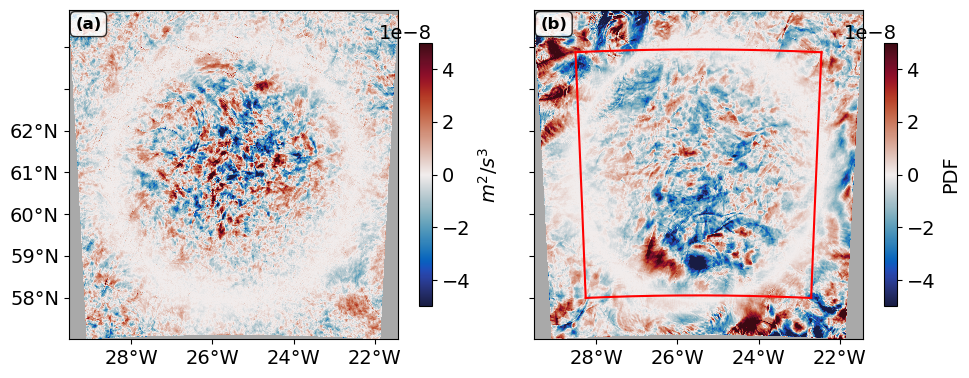

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax1, ax2 = axes[0], axes[1]

# 左图：能量通量
ax1.set_facecolor('darkgrey')
mesh1 = ax1.pcolormesh(lonr, latr, np.squeeze((np.nanmean(Th4w, axis=0))), 
                       cmap=cm.balance, vmin=-cgmax, vmax=cgmax)
# 边框
for arr in [lonr[:,0], lonr[:,-1], lonr[0,:], lonr[-1,:]]:
    ax1.plot(arr[:,0] if arr.ndim > 1 else arr, 
             arr[:,-1] if arr.ndim > 1 else arr, 
             color='k', linewidth=1.5)

# 右图：粒子密度
ax2.set_facecolor('darkgrey')
mesh2 = ax2.pcolormesh(lonr, latr, np.squeeze((np.nanmean(Th4nw, axis=0))), 
                       cmap=cm.balance, vmin=-cgmax, vmax=cgmax)
# 边框
for arr in [lonr[:,0], lonr[:,-1], lonr[0,:], lonr[-1,:]]:
    ax2.plot(arr[:,0] if arr.ndim > 1 else arr, 
             arr[:,-1] if arr.ndim > 1 else arr, 
             color='k', linewidth=1.5)
# 红色框
lay = 105
lonr2 = lonr[lay:-lay, lay:-lay]
latr2 = latr[lay:-lay, lay:-lay]
for arr_x, arr_y in [(lonr2[:,0], latr2[:,0]), (lonr2[:,-1], latr2[:,-1]), 
                     (lonr2[0,:], latr2[0,:]), (lonr2[-1,:], latr2[-1,:])]:
    ax2.plot(arr_x, arr_y, color='r', linewidth=1.5)

# 设置坐标轴
for ax in [ax1, ax2]:
    ax.set_xlim(lonr.min(), lonr.max())
    ax.set_ylim(latr.min(), latr.max())
    ax.set_xticklabels([format_coordinate(x, 'lon') for x in ax.get_xticks()])
    ax.set_yticklabels([format_coordinate(y, 'lat') for y in ax.get_yticks()])

# 移除右图的y轴标签
ax2.set_yticklabels('')

# 添加标签
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, 
         fontsize=12, va='top', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, 
         fontsize=12, va='top', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 颜色条
plt.colorbar(mesh1, ax=ax1, label=r'$m^2/s^3$', shrink=0.8)
plt.colorbar(mesh2, ax=ax2, label='PDF', shrink=0.8)

plt.tight_layout()
# plt.savefig('simple_1x2_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# axx=ax4
# axx.set_facecolor('darkgrey')
# mesh = axx.pcolormesh(lonr, latr, np.squeeze((np.nanmean(Th4w,axis=0))),cmap=cm.balance,vmin=-cgmax,vmax=cgmax)
# # plt.colorbar(mesh, label='Particle Density ')
# axx.set_xticklabels([format_coordinate(x, 'lon') for x in ax1.get_xticks()])
# axx.set_yticklabels([format_coordinate(y, 'lat') for y in ax1.get_yticks()])
# axx.set_yticklabels('')
# axx.plot(lonr[:,0], latr[:,0], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[:,-1], latr[:,-1], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[0,:], latr[0,:], color='k', linestyle='-',linewidth=1.5)
# axx.plot(lonr[-1,:], latr[-1,:], color='k', linestyle='-',linewidth=1.5)